<a href="https://colab.research.google.com/github/AcostaAlex10/hackathon-kit-Acosta-Borges-Pelinski/blob/main/eda_y_benchmark__base4.5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EDA y benchmark multimodelo — Desafío Machine Health

Sesión de la mañana del jueves. Objetivo: establecer el **techo de rendimiento
con datos exclusivamente tabulares**, antes de invertir la tarde en las señales
crudas.

Alcance de este notebook, deliberadamente acotado:

- Sólo `train_sup.parquet` y `test.parquet`. **El procesamiento de NPZ queda
  fuera** de esta etapa.
- Sólo la métrica oficial (`scoring.compute_score`). No se decide nada por
  accuracy ni logloss: la métrica es compuesta y no correlaciona con ellas.
- Validación `StratifiedGroupKFold(5)` agrupada por `machine_id`, sin excepción.

Contexto y hallazgos previos en `estrategia1_Borges.md`. Los tres que gobiernan
este notebook:

1. **No es multilabel.** `is_combo` vale 0 en las 1750 filas etiquetadas: cada
   ventana tiene exactamente 0 o 1 falla. Se modela como softmax de 14 estados.
2. **Train y test no comparten ninguna máquina.** De ahí la normalización por
   `machine_id` de la sección 2 y el agrupamiento de la validación.
3. **La capa de decisión de la métrica ya es óptima.** No se afilan ni se
   distorsionan las probabilidades: sólo se predice mejor.

## 0. Entorno

In [1]:
import requests
import zipfile
import io
import os

# URL de descarga directa del archivo ZIP de Google Drive
# (Necesitas obtener la URL de descarga directa, el formato puede variar)
# Por ejemplo: 'https://drive.google.com/uc?export=download&id=YOUR_FILE_ID'
# Reemplaza 'YOUR_FILE_ID' con el ID del archivo en tu enlace.
# Para el enlace proporcionado 'https://drive.google.com/uc?id=1FKuxVH--rRJiK8tzfT_T8BW1WVj8v6wV'
# el ID del archivo es '1FKuxVH--rRJiK8tzfT_T8BW1WVj8v6wV'

# La URL proporcionada ya es un enlace de descarga directa de Google Drive.
zip_file_url = 'https://drive.google.com/uc?id=1FKuxVH--rRJiK8tzfT_T8BW1WVj8v6wV'
output_dir = './data_from_drive/' # Directorio donde se extraerán los archivos

print(f"Descargando archivo ZIP desde: {zip_file_url}")
response = requests.get(zip_file_url)
response.raise_for_status() # Lanza una excepción si la descarga falla

# Crear el directorio de salida si no existe
os.makedirs(output_dir, exist_ok=True)

# Descomprimir el archivo en el directorio especificado
with zipfile.ZipFile(io.BytesIO(response.content)) as zf:
    zf.extractall(output_dir)

print(f"Archivos descomprimidos en: {output_dir}")
print("Listado de archivos extraídos:")
for root, dirs, files in os.walk(output_dir):
    for name in files:
        print(os.path.join(root, name))
    for name in dirs:
        print(os.path.join(root, name) + '/')


Descargando archivo ZIP desde: https://drive.google.com/uc?id=1FKuxVH--rRJiK8tzfT_T8BW1WVj8v6wV
Archivos descomprimidos en: ./data_from_drive/
Listado de archivos extraídos:
./data_from_drive/participant_kit/
./data_from_drive/participant_kit/scoring.py
./data_from_drive/participant_kit/requirements.txt
./data_from_drive/participant_kit/eda_intro.ipynb
./data_from_drive/participant_kit/baseline.ipynb
./data_from_drive/participant_kit/__init__.py
./data_from_drive/participant_kit/baseline.py
./data_from_drive/participant_kit/README.md
./data_from_drive/participant_kit/convert_raw_to_csv.py
./data_from_drive/participant_kit/outputs/
./data_from_drive/participant_kit/outputs/baseline_submission.csv


In [2]:
# Nueva URL de descarga directa del archivo ZIP de Google Drive
new_zip_file_url = 'https://drive.google.com/uc?id=1fd4f0MuMiuUT0IEZxfLONMF6gD4hGIND'
new_output_dir = './data_challenge_new/' # Directorio donde se extraerán los archivos

print(f"Descargando archivo ZIP desde: {new_zip_file_url}")
response = requests.get(new_zip_file_url)
response.raise_for_status() # Lanza una excepción si la descarga falla

# Crear el directorio de salida si no existe
os.makedirs(new_output_dir, exist_ok=True)

# Descomprimir el archivo en el directorio especificado
with zipfile.ZipFile(io.BytesIO(response.content)) as zf:
    zf.extractall(new_output_dir)

print(f"Archivos descomprimidos en: {new_output_dir}")
print("Listado de archivos extraídos del nuevo ZIP:")
for root, dirs, files in os.walk(new_output_dir):
    for name in files:
        print(os.path.join(root, name))
    for name in dirs:
        print(os.path.join(root, name) + '/')


Descargando archivo ZIP desde: https://drive.google.com/uc?id=1fd4f0MuMiuUT0IEZxfLONMF6gD4hGIND
Archivos descomprimidos en: ./data_challenge_new/
Listado de archivos extraídos del nuevo ZIP:
./data_challenge_new/datos_sinraw/
./data_challenge_new/datos_sinraw/checksums.txt
./data_challenge_new/datos_sinraw/raw_signal_index.csv
./data_challenge_new/datos_sinraw/data_dictionary.csv
./data_challenge_new/datos_sinraw/train_sup.parquet
./data_challenge_new/datos_sinraw/train_sup.csv
./data_challenge_new/datos_sinraw/test.csv
./data_challenge_new/datos_sinraw/train_unlabeled.csv
./data_challenge_new/datos_sinraw/train_unlabeled.parquet
./data_challenge_new/datos_sinraw/test.parquet
./data_challenge_new/datos_sinraw/raw_signal_index.parquet


In [3]:
# Colab: descomentar. En local, si ya están instaladas, saltear.
# !pip -q install lightgbm xgboost catboost pyarrow

import os, sys, warnings, itertools
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Carpeta con train_sup.parquet / test.parquet y con scoring.py del kit de la
# cátedra. Ajustar a donde estén montados los datos.
DATA = Path("data_challenge_new/datos_sinraw")
KIT  = Path("data_from_drive/participant_kit")

sys.path.insert(0, str(KIT))
sys.path.insert(0, str(KIT.parent))
import scoring
from scoring import compute_score, FAULT_IDS, LABEL_COLUMNS, FAMILIES

print("scoring cargado |", len(FAULT_IDS), "fallas |", sorted(set(FAMILIES.values())))


scoring cargado | 13 fallas | ['electrical', 'hydraulic', 'mechanical', 'structural']


In [4]:
from pathlib import Path
import pandas as pd
import numpy as np
import sys

# Añadir el directorio del kit de participantes al path para que Python encuentre 'baseline'
sys.path.append('./data_from_drive/participant_kit/')

from baseline import (
    read_table, find_table, split_by_machine,
    estimate_prevalences, prevalence_submission,
)
from scoring import compute_score, validate_prediction_package, FAULT_IDS

# Ajustar DATA_DIR para que apunte a la carpeta donde se extrajeron train_sup.csv y test.csv
DATA_DIR = Path('./data_challenge_new/datos_sinraw/') # Ruta correcta de los datos
OUTPUT_DIR = Path('./outputs')

LABEL_COLS = [f'label_{f}' for f in FAULT_IDS]
SEVERITY_COLS = [f'severity_{f}' for f in FAULT_IDS]

In [5]:
train = read_table(find_table(DATA_DIR, 'train_sup'))
test = read_table(find_table(DATA_DIR, 'test'))
print(f'train_sup: {train.shape}  (filas, columnas)')
print(f'test:      {test.shape}')
print(f'Máquinas en train: {train.machine_id.nunique()}')
print(f'Sesiones en train: {train.session_id.nunique()}')
train[['window_id', 'machine_id', 'session_id']].head()

train_sup: (1750, 77)  (filas, columnas)
test:      (1848, 49)
Máquinas en train: 26
Sesiones en train: 250


,window_id,machine_id,session_id
0,W0511a7920bdf7d480000,M0000022,S0511a7920bdf7d48
1,W0511a7920bdf7d480001,M0000022,S0511a7920bdf7d48
2,W0511a7920bdf7d480002,M0000022,S0511a7920bdf7d48
3,W0511a7920bdf7d480003,M0000022,S0511a7920bdf7d48
4,W0511a7920bdf7d480004,M0000022,S0511a7920bdf7d48


## 1. Carga y EDA rápido

La validación que interesa acá no es "¿hay nulos?" sino **¿la estructura del
target es la que dice la consigna?**. La consigna describe un problema
multilabel con estados combinados; los datos dicen otra cosa, y de esa
diferencia sale la decisión de modelado.

In [6]:
train = pd.read_parquet(DATA / "train_sup.parquet")
test  = pd.read_parquet(DATA / "test.parquet")

print("train", train.shape, "| test", test.shape)
print("máquinas -> train %d, test %d, intersección %d"
      % (train.machine_id.nunique(), test.machine_id.nunique(),
         len(set(train.machine_id) & set(test.machine_id))))
print("sesiones -> train %d, test %d, intersección %d"
      % (train.session_id.nunique(), test.session_id.nunique(),
         len(set(train.session_id) & set(test.session_id))))

train (1750, 77) | test (1848, 49)
máquinas -> train 26, test 22, intersección 0
sesiones -> train 250, test 264, intersección 0


In [7]:
# Limpieza: estas tablas vienen sintéticas y limpias. Se verifica, no se asume.
faltantes = train.isna().sum()
print("columnas con nulos:", int((faltantes > 0).sum()))
print("filas duplicadas   :", int(train.duplicated().sum()))
print("window_id únicos   :", train.window_id.is_unique, "|", test.window_id.is_unique)

constantes = [c for c in train.columns if train[c].nunique(dropna=False) <= 1]
print("columnas constantes:", constantes)

columnas con nulos: 0
filas duplicadas   : 0
window_id únicos   : True | True
columnas constantes: ['temp_winding__nan_frac', 'temp_bearing1__nan_frac', 'temp_bearing2__nan_frac', 'is_combo']


### Estructura del target

`is_combo` marca las ventanas con más de una falla simultánea. Si vale 0 en
todas las filas, el problema colapsa de 13 etiquetas independientes a **14
estados mutuamente excluyentes**, y conviene un softmax en vez de 13 binarios:
las probabilidades salen coherentes entre sí y suman ≤ 1, que es exactamente lo
que consume `choose_action` de la métrica.

In [8]:
labels = train[LABEL_COLUMNS].to_numpy()
n_fallas = labels.sum(axis=1)

print("fallas por ventana:", pd.Series(n_fallas).value_counts().sort_index().to_dict())
print("is_combo.mean() = %.3f" % train.is_combo.mean())
print("E[#fallas] = %.3f  |  P(al menos una falla) = %.3f"
      % (n_fallas.mean(), (n_fallas > 0).mean()))

assert train.is_combo.sum() == 0, "hay combos: revisar la hipótesis de 14 estados"
assert set(np.unique(n_fallas)) <= {0, 1}, "alguna ventana tiene más de una falla"
print("\nconfirmado: cada ventana tiene exactamente 0 o 1 falla -> 14 estados")

# estado 0 = sano; estado k = falla F{k}
estado = np.where(n_fallas == 0, 0, labels.argmax(axis=1) + 1)
ESTADOS = ["sano"] + FAULT_IDS

fallas por ventana: {0: 217, 1: 1533}
is_combo.mean() = 0.000
E[#fallas] = 0.876  |  P(al menos una falla) = 0.876

confirmado: cada ventana tiene exactamente 0 o 1 falla -> 14 estados


### Prevalencia de las 14 clases

,n,prevalencia,familia
sano,217,0.124,sano
F01,168,0.096,mechanical
F02,168,0.096,mechanical
F03,161,0.092,mechanical
F04,98,0.056,mechanical
F05,112,0.064,mechanical
F06,105,0.060,mechanical
F07,91,0.052,structural
F08,112,0.064,electrical
F09,84,0.048,electrical


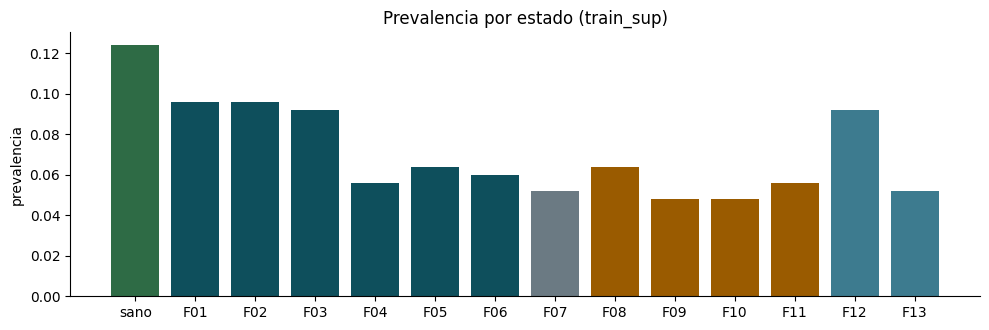

severidad: de las ventanas CON falla, 57.5 % son severas (max_severity > 0.5)


In [9]:
prev = (pd.Series(estado).value_counts().sort_index()
        .rename(index=lambda k: ESTADOS[k]).to_frame("n"))
prev["prevalencia"] = prev.n / len(train)
prev["familia"] = ["sano"] + [FAMILIES[f] for f in FAULT_IDS]
display(prev)

fig, ax = plt.subplots(figsize=(10, 3.4))
colores = {"sano": "#2E6B45", "mechanical": "#0E4F5C", "structural": "#6B7A83",
           "electrical": "#9A5B00", "hydraulic": "#3D7B8F"}
ax.bar(prev.index, prev.prevalencia, color=[colores[f] for f in prev.familia])
ax.set_ylabel("prevalencia"); ax.set_title("Prevalencia por estado (train_sup)")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

print("severidad: de las ventanas CON falla, %.1f %% son severas (max_severity > 0.5)"
      % (100 * (train.loc[n_fallas > 0, [f"severity_{f}" for f in FAULT_IDS]].max(axis=1) > 0.5).mean()))

El desbalance es moderado (de 4.8 % a 9.6 % por falla, 12.4 % sano). No hace
falta remuestrear: lo que castiga la métrica no es el desbalance sino la
confusión **entre familias**, porque `cost_score` — que pesa 70 % — sólo
distingue las cuatro familias más el estado sano.

## 2. Mitigación del covariate shift

Train y test no comparten ninguna máquina. Cada máquina tiene su punto de
trabajo propio (rpm, temperatura, caudal), así que los valores **absolutos** de
los sensores identifican a la máquina más que al estado de salud. Un modelo
entrenado sobre valores absolutos aprende las 26 máquinas del train y no
generaliza a las 22 del test.

La corrección es expresar cada variable como desviación respecto del
comportamiento habitual de su propia máquina:

$$z_{i,c} = \frac{x_{i,c} - \mathrm{mediana}_{m(i)}(x_c)}{\mathrm{desvío}_{m(i)}(x_c) + \varepsilon}$$

Se usa **mediana** y no media por robustez ante las ventanas en falla, que son
justamente las colas de la distribución de cada máquina.

Esto es legítimo sobre el test: usa sólo las columnas de features y el
`machine_id`, nunca las etiquetas. Se calcula por separado en cada tabla.

In [10]:
EXCLUIR = set(["window_id", "machine_id", "session_id", "is_normal", "is_combo"]
              + LABEL_COLUMNS + [f"severity_{f}" for f in FAULT_IDS])
FEATS = [c for c in train.columns if c not in EXCLUIR]
print("features tabulares originales:", len(FEATS))

def zscore_por_maquina(df, cols):
    """Desviación respecto de la propia máquina. No mira etiquetas."""
    g = df.groupby("machine_id")[cols]
    z = (df[cols] - g.transform("median")) / (g.transform("std") + 1e-9)
    z.columns = [c + "__z" for c in cols]
    return z

def construir_X(df):
    return pd.concat([df[FEATS], zscore_por_maquina(df, FEATS)], axis=1)

X_train, X_test = construir_X(train), construir_X(test)
print("matriz final:", X_train.shape, "(originales + z-score)")

features tabulares originales: 46
matriz final: (1750, 92) (originales + z-score)


### Verificación gráfica del alineamiento

Un KDE de train contra test, antes y después. Si la normalización funciona, las
dos curvas se superponen en el panel derecho.

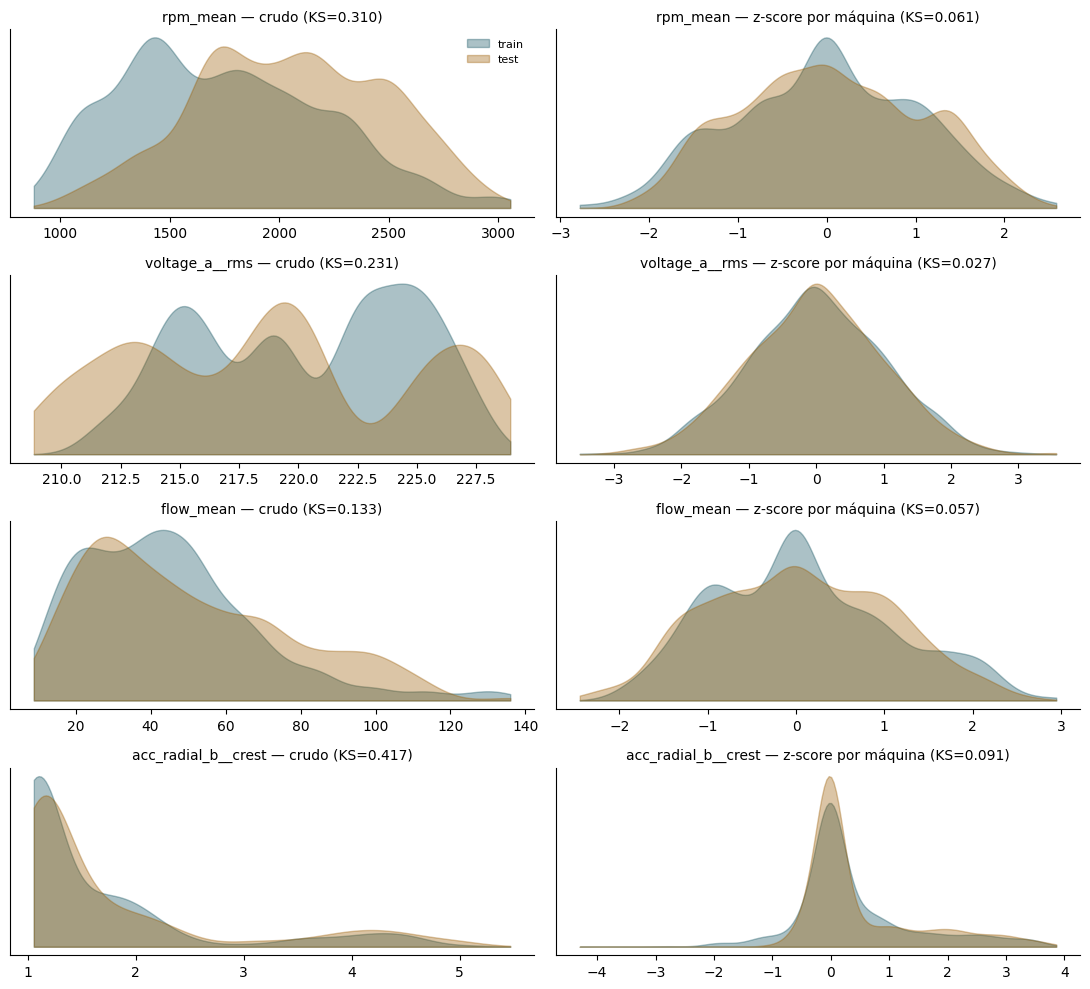

In [11]:
from scipy.stats import gaussian_kde, ks_2samp

CRITICAS = ["rpm_mean", "voltage_a__rms", "flow_mean", "acc_radial_b__crest"]

def kde(ax, a, b, titulo):
    grid = np.linspace(min(a.min(), b.min()), max(a.max(), b.max()), 200)
    ax.fill_between(grid, gaussian_kde(a)(grid), color="#0E4F5C", alpha=.35, label="train")
    ax.fill_between(grid, gaussian_kde(b)(grid), color="#9A5B00", alpha=.35, label="test")
    ax.set_title(titulo, fontsize=10)
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_yticks([])

fig, axes = plt.subplots(len(CRITICAS), 2, figsize=(11, 2.5 * len(CRITICAS)))
for fila, c in enumerate(CRITICAS):
    ks_c = ks_2samp(train[c], test[c]).statistic
    ks_z = ks_2samp(X_train[c + "__z"].dropna(), X_test[c + "__z"].dropna()).statistic
    kde(axes[fila, 0], train[c].values, test[c].values, f"{c} — crudo (KS={ks_c:.3f})")
    kde(axes[fila, 1], X_train[c + "__z"].dropna().values, X_test[c + "__z"].dropna().values,
        f"{c} — z-score por máquina (KS={ks_z:.3f})")
axes[0, 0].legend(fontsize=8, frameon=False)
plt.tight_layout(); plt.show()

In [12]:
# Efecto sobre las 46 variables, no sólo sobre las cuatro del gráfico.
ks_crudo = [ks_2samp(train[c], test[c]).statistic for c in FEATS]
ks_norm  = [ks_2samp(X_train[c + "__z"].dropna(), X_test[c + "__z"].dropna()).statistic
            for c in FEATS]

print("KS medio train vs test:  crudo = %.3f   ->   z-score = %.3f"
      % (np.mean(ks_crudo), np.mean(ks_norm)))
print("variables con KS > 0.2:  crudo = %d      ->   z-score = %d"
      % (sum(k > .2 for k in ks_crudo), sum(k > .2 for k in ks_norm)))

KS medio train vs test:  crudo = 0.139   ->   z-score = 0.059
variables con KS > 0.2:  crudo = 11      ->   z-score = 0


Las 11 variables que estaban claramente desalineadas quedan en cero, y el KS
medio cae a menos de la mitad. Se **conservan las dos versiones** de cada
variable: los valores absolutos siguen teniendo información física real
(una temperatura de devanado alta es alta en cualquier máquina) y los árboles
eligen cuál usar.

## 2.5 EDA supervisado: ¿qué información contienen las features?


--- Análisis detallado para algunas features críticas (Distribución y Outliers - SOLO Original) ---


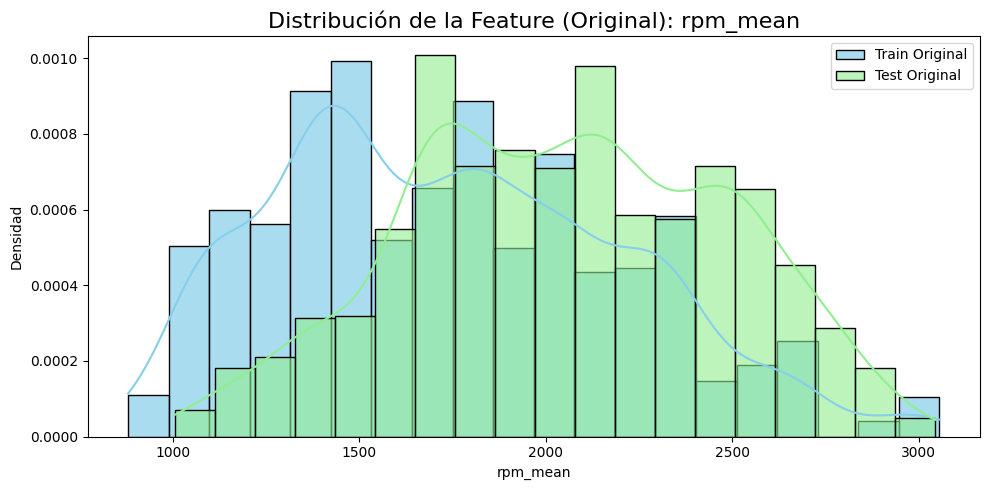

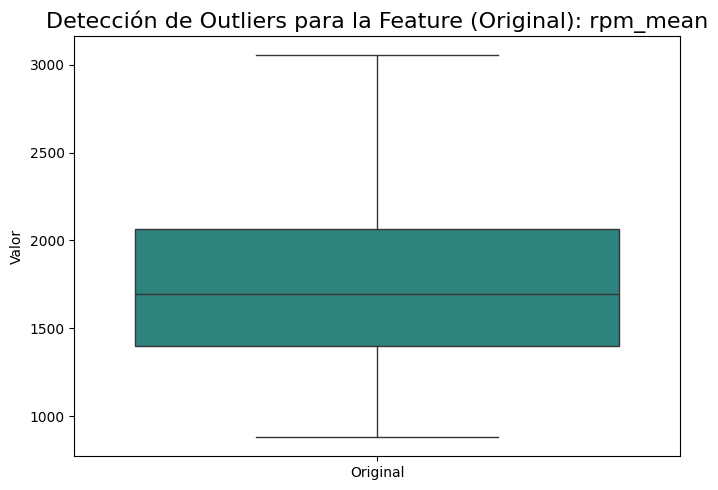

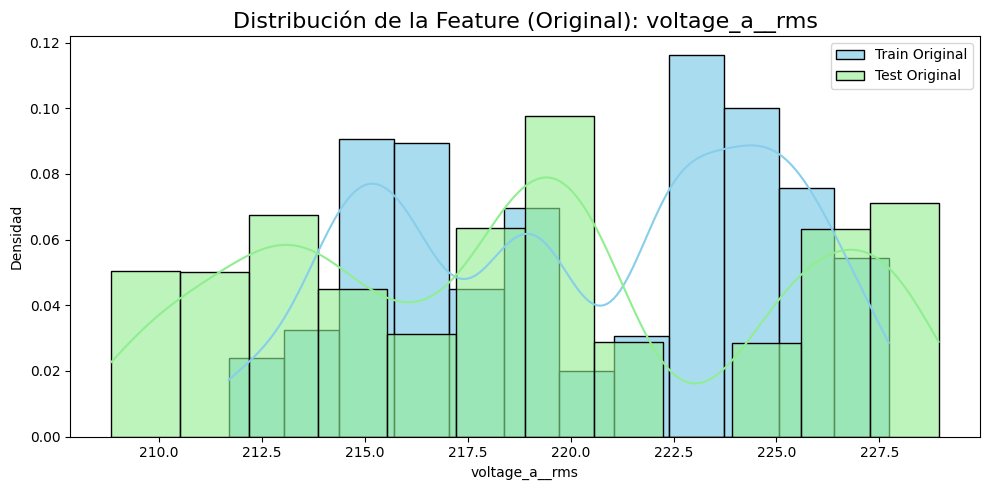

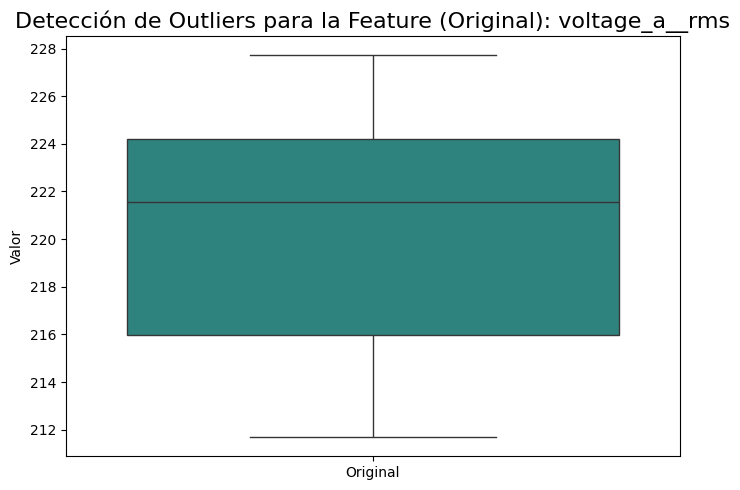

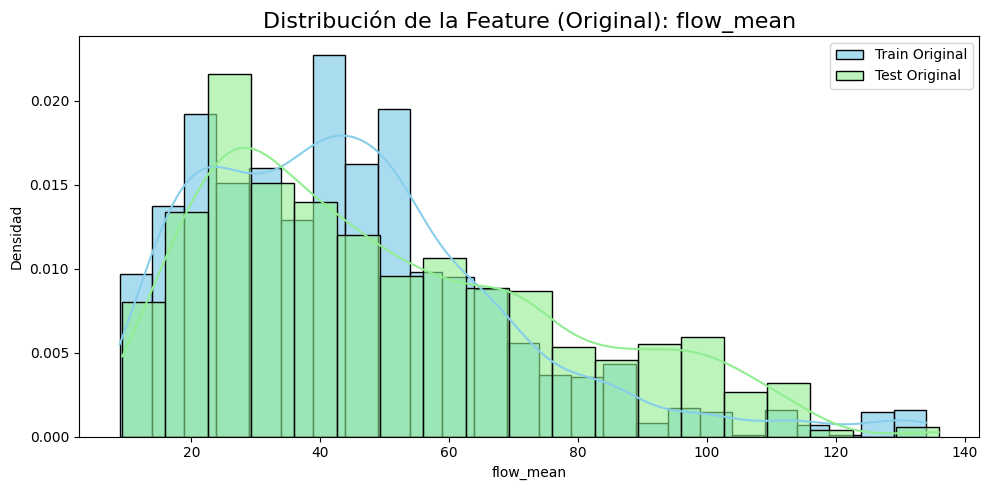

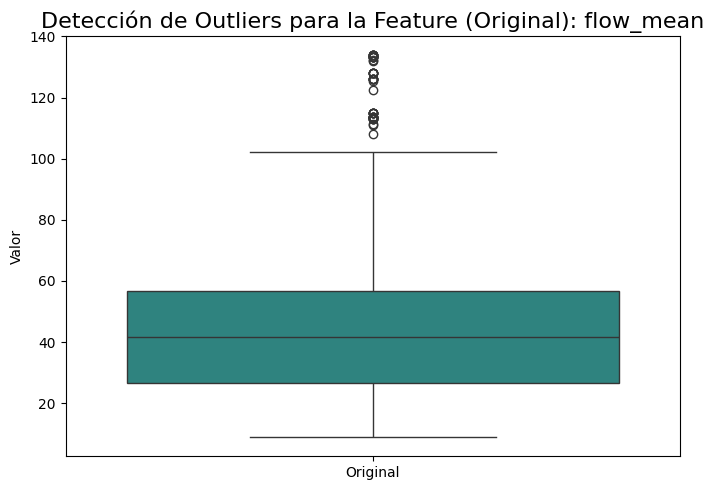

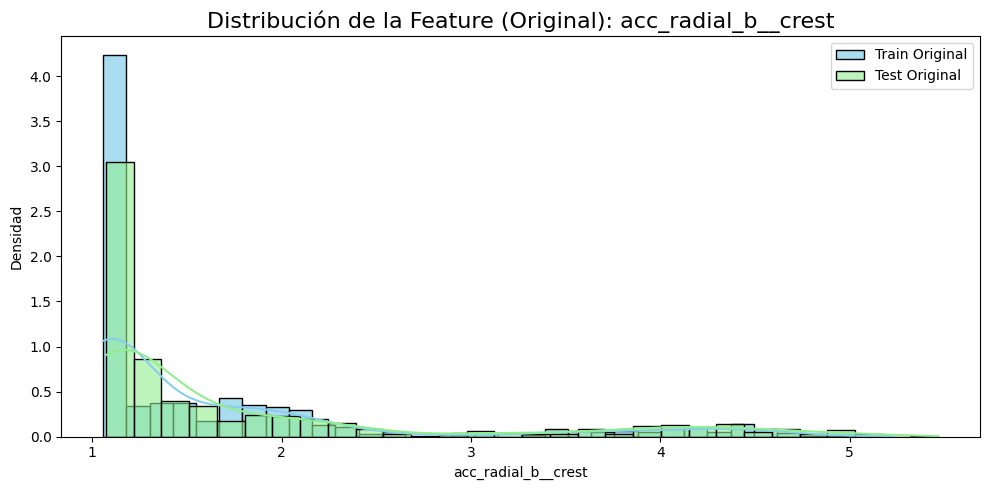

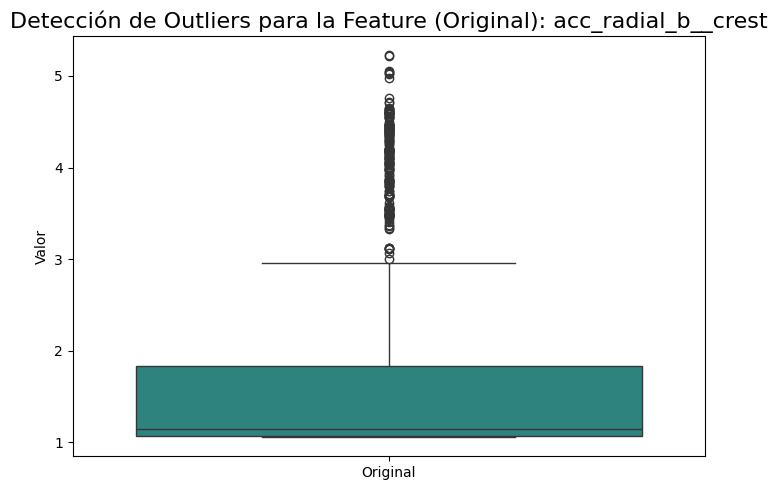


--- Matriz de Correlación de todas las Features (Originales y Z-scored) ---


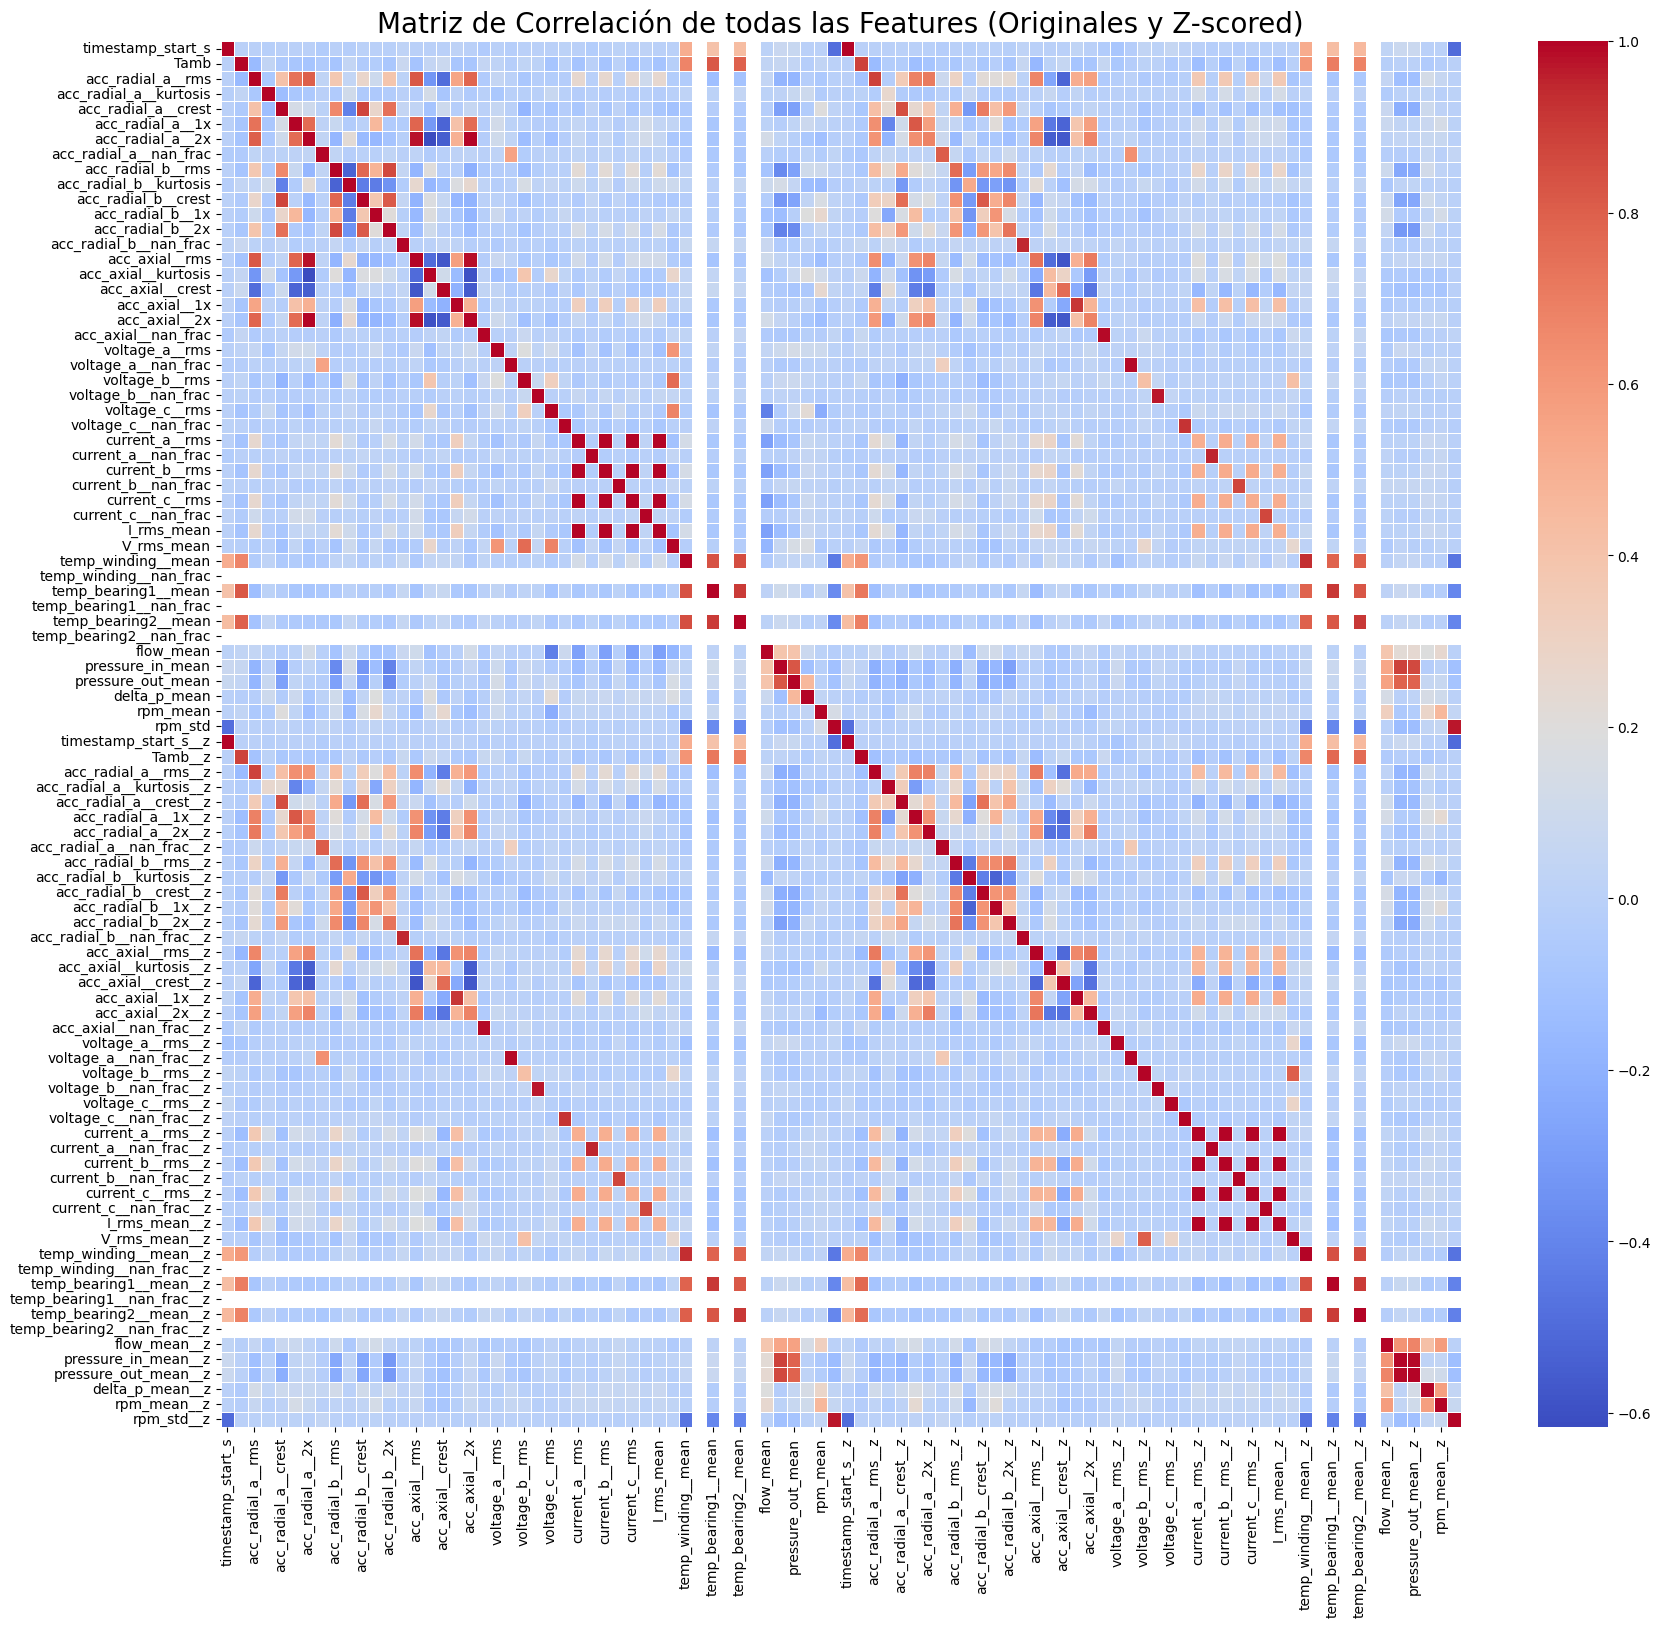

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Assuming FEATS, X_train, X_test, CRITICAS are defined in previous cells

def plot_feature_distribution(feature_name, df_train, df_test=None):
    """
    Plots the distribution (histplot) for a given feature (original only).
    Optionally includes test data distribution.
    """
    plt.figure(figsize=(10, 5))
    sns.histplot(df_train[feature_name], kde=True, color='skyblue', label='Train Original', stat='density', alpha=0.7)
    if df_test is not None:
        sns.histplot(df_test[feature_name], kde=True, color='lightgreen', label='Test Original', stat='density', alpha=0.6)

    plt.title(f'Distribución de la Feature (Original): {feature_name}', fontsize=16)
    plt.xlabel(feature_name)
    plt.ylabel('Densidad')
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_feature_boxplot(feature_name, df_train):
    """
    Plots boxplots for a given feature (original only) to show outliers.
    """
    plt.figure(figsize=(7, 5))
    data_to_plot_boxplot = pd.DataFrame({
        'Original': df_train[feature_name]
    })
    sns.boxplot(data=data_to_plot_boxplot, palette='viridis')
    plt.title(f'Detección de Outliers para la Feature (Original): {feature_name}', fontsize=16)
    plt.ylabel('Valor')
    plt.tight_layout()
    plt.show()

print("\n--- Análisis detallado para algunas features críticas (Distribución y Outliers - SOLO Original) ---")
# Use CRITICAS defined earlier for a focused analysis
for feat in CRITICAS:
    plot_feature_distribution(feat, X_train, X_test)
    plot_feature_boxplot(feat, X_train)

print("\n--- Matriz de Correlación de todas las Features (Originales y Z-scored) ---")
# Correlation Matrix for X_train (including original and z-scored features)
corr_matrix = X_train.corr()

# Plotting the correlation matrix
plt.figure(figsize=(20, 18))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlación de todas las Features (Originales y Z-scored)', fontsize=20)
plt.show()


--- Gráfico de Dispersión (Pairplot) para Features Altamente Correlacionadas ---
Advertencia: Se encontraron 64 features altamente correlacionadas. Mostrando un subconjunto de 8 para mayor claridad.
Generando pairplot para las siguientes features altamente correlacionadas (8):
['I_rms_mean', 'I_rms_mean__z', 'Tamb', 'Tamb__z', 'V_rms_mean', 'V_rms_mean__z', 'acc_axial__1x', 'acc_axial__1x__z']


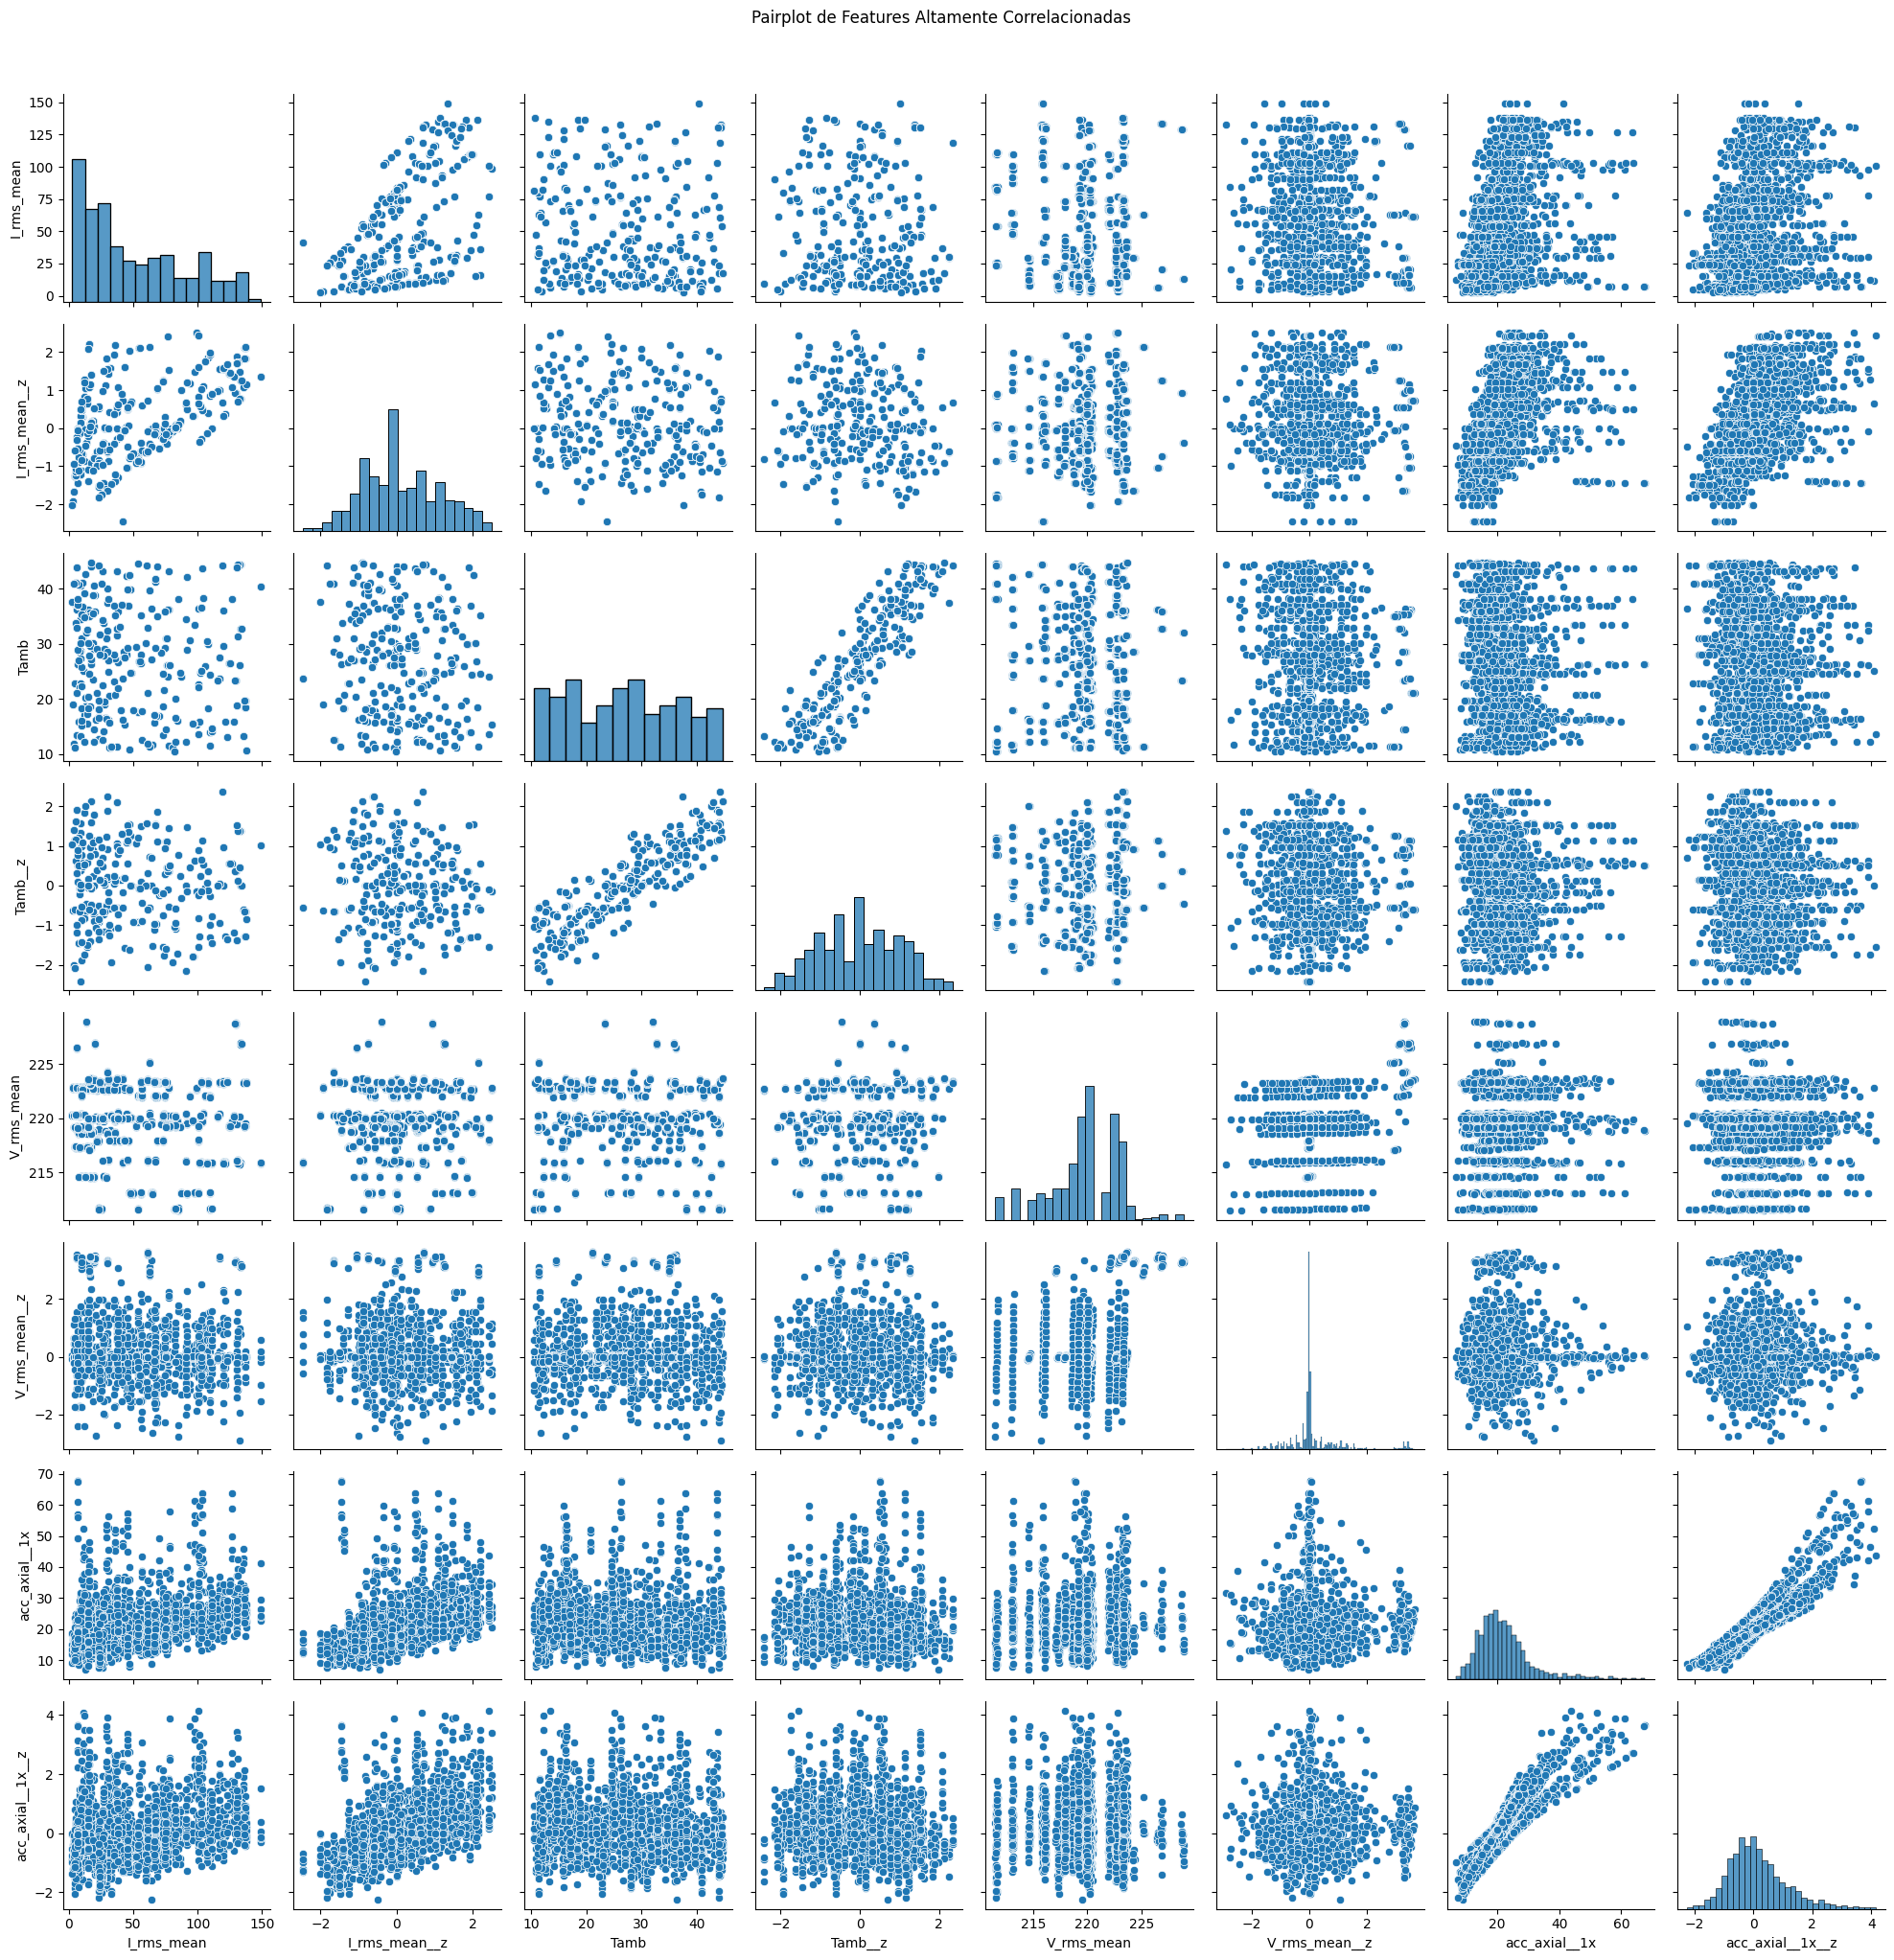

In [15]:
print("\n--- Gráfico de Dispersión (Pairplot) para Features Altamente Correlacionadas ---")

# Definir un umbral de correlación
correlation_threshold = 0.75

# Encontrar pares de features altamente correlacionadas (evitando duplicados y auto-correlación)
high_corr_features = set()
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > correlation_threshold:
            colname_i = corr_matrix.columns[i]
            colname_j = corr_matrix.columns[j]
            high_corr_features.add(colname_i)
            high_corr_features.add(colname_j)

# Convertir a lista y ordenar para consistencia
high_corr_features = sorted(list(high_corr_features))

# Limitar el número de features para el pairplot si hay demasiadas
# Un pairplot con demasiadas variables puede ser difícil de interpretar y muy lento
max_pairplot_features = 8 # Puedes ajustar este número
if len(high_corr_features) > max_pairplot_features:
    print(f"Advertencia: Se encontraron {len(high_corr_features)} features altamente correlacionadas. Mostrando un subconjunto de {max_pairplot_features} para mayor claridad.")
    # Estrategia simple: tomar las primeras 'max_pairplot_features'
    # Podrías implementar una lógica más sofisticada aquí (ej. las que tienen la correlación más alta con el target)
    selected_features_for_pairplot = high_corr_features[:max_pairplot_features]
else:
    selected_features_for_pairplot = high_corr_features

if not selected_features_for_pairplot:
    print(f"No se encontraron features con correlación absoluta mayor a {correlation_threshold}. No se generará pairplot.")
elif len(selected_features_for_pairplot) == 1:
    print(f"Solo se encontró una feature altamente correlacionada: {selected_features_for_pairplot[0]}. No se generará pairplot.")
else:
    print(f"Generando pairplot para las siguientes features altamente correlacionadas ({len(selected_features_for_pairplot)}):\n{selected_features_for_pairplot}")
    # Usar X_train para el pairplot
    sns.pairplot(X_train[selected_features_for_pairplot])
    plt.suptitle('Pairplot de Features Altamente Correlacionadas', y=1.02) # Ajustar el título
    plt.tight_layout()
    plt.show()

### Feature Engineening: Variables Físicas

In [16]:
FAMS = sorted(set(FAMILIES.values()))
FIDX = {g: np.array([i for i, f in enumerate(FAULT_IDS) if FAMILIES[f] == g]) for g in FAMS}

def acciones(P13):
    S = P13.sum(1); n = len(P13)
    c = np.empty((n, 3 + len(FAMS)))
    c[:, 0] = 10 * S; c[:, 1] = 7 + 3.5 * S; c[:, 2] = 12
    for k, g in enumerate(FAMS):
        c[:, 3 + k] = 4 + 8 * (S - P13[:, FIDX[g]].sum(1))
    nom = np.array(["MONITOR", "DERATE", "STOP"] + ["INSPECT_" + g for g in FAMS])
    return pd.Series(nom[c.argmin(1)])

# Modificado: P0 debe ser solo las probabilidades numéricas de las 13 fallas (no 'sano')
P0 = np.tile(prev.loc[FAULT_IDS, "prevalencia"].to_numpy(), (len(train), 1))
print("acciones que elige la regla para el baseline P0:")
print(acciones(P0).value_counts().to_string())

acciones que elige la regla para el baseline P0:
INSPECT_mechanical    1750


In [17]:
def evaluar(P13, df=train, idx=None):
    idx = np.arange(len(df)) if idx is None else idx
    e = pd.DataFrame({"window_id": df.window_id.iloc[idx].to_numpy()})
    for j, f in enumerate(FAULT_IDS): e[f] = np.clip(P13[idx][:, j], 0, 1)
    return compute_score(df.iloc[idx], e)["overall"]

r0 = evaluar(P0); ro = evaluar(train[LABEL_COLUMNS].to_numpy(float))
print("P0 prevalencia  final=%6.2f  cost=%6.2f" % (r0["final_score"], r0["cost_score"]))
print("oráculo         final=%6.2f  cost=%6.2f" % (ro["final_score"], ro["cost_score"]))
print("\nnaive_cost=%.2f. Aun acertando todo hay que pagar la inspección de $4," % r0["naive_cost"])
print("por eso cost_score se planta en %.1f y el final máximo del problema es %.1f."
      % (ro["cost_score"], ro["final_score"]))

P0 prevalencia  final= 30.78  cost= 22.55
oráculo         final= 73.96  cost= 62.80

naive_cost=9.42. Aun acertando todo hay que pagar la inspección de $4,
por eso cost_score se planta en 62.8 y el final máximo del problema es 74.0.


In [18]:
BASE = [c for c in test.columns
        if c not in ("window_id", "machine_id", "session_id", "timestamp_start_s")]
ACC = ["acc_radial_a", "acc_radial_b", "acc_axial"]

def fisicas(df):
    X = pd.DataFrame(index=df.index)
    rpm = df.rpm_mean.clip(lower=1) / 1000.0
    rpm2 = rpm ** 2
    for a in ACC:
        rms = df[f"{a}__rms"].clip(lower=1e-9)
        X[f"{a}__rms_n"] = rms / rpm2
        X[f"{a}__1x_r"]  = df[f"{a}__1x"] / (rms ** 2 + 1e-9)
        X[f"{a}__2x1x"]  = df[f"{a}__2x"] / (df[f"{a}__1x"].abs() + 1e-6)
        X[f"{a}__lkurt"] = np.log1p(df[f"{a}__kurtosis"].clip(lower=0))
        X[f"{a}__crest_n"] = df[f"{a}__crest"]
    ra = df["acc_radial_a__rms"].clip(lower=1e-9)
    X["ax_rad"]  = df["acc_axial__rms"] / ra
    X["rad_b_a"] = df["acc_radial_b__rms"] / ra
    X["vib_tot"] = df[[f"{a}__rms" for a in ACC]].sum(1) / rpm2
    V = df[["voltage_a__rms", "voltage_b__rms", "voltage_c__rms"]]
    I = df[["current_a__rms", "current_b__rms", "current_c__rms"]]
    vm, im = V.mean(1).clip(lower=1e-9), I.mean(1).clip(lower=1e-9)
    X["V_desbal"] = (V.max(1) - V.min(1)) / vm
    X["I_desbal"] = (I.max(1) - I.min(1)) / im
    X["V_cv"] = V.std(1) / vm
    X["I_cv"] = I.std(1) / im
    X["I_min_r"] = I.min(1) / im
    X["I_max_r"] = I.max(1) / im
    X["S_ap"] = im * vm / 1000.0
    X["I_por_rpm"]  = im / rpm
    X["I_por_flow"] = im / (df.flow_mean.abs() + 1e-6)
    X["dT_wind"]   = df["temp_winding__mean"] - df.Tamb
    X["dT_b1"]     = df["temp_bearing1__mean"] - df.Tamb
    X["dT_b2"]     = df["temp_bearing2__mean"] - df.Tamb
    X["dT_b1b2"]   = df["temp_bearing1__mean"] - df["temp_bearing2__mean"]
    X["dT_wind_b"] = df["temp_winding__mean"] - df[["temp_bearing1__mean", "temp_bearing2__mean"]].mean(1)
    X["dT_wind_rpm"] = X["dT_wind"] / rpm
    X["head_n"]    = df.delta_p_mean / rpm2
    X["flow_n"]    = df.flow_mean / rpm
    X["p_in_n"]    = df.pressure_in_mean / rpm2
    X["p_ratio"]   = df.pressure_out_mean / (df.pressure_in_mean.abs() + 1e-6)
    X["hidr_pot"]  = df.flow_mean * df.delta_p_mean / (im * vm + 1e-6)
    X["flow_head"] = df.flow_mean / (df.delta_p_mean.abs() + 1e-6)
    X["rpm_cv"] = df.rpm_std / df.rpm_mean.clip(lower=1)
    nanc = [c for c in df.columns if c.endswith("__nan_frac")]
    X["nan_tot"] = df[nanc].sum(1)
    X["nan_max"] = df[nanc].max(1)
    return X.replace([np.inf, -np.inf], np.nan).fillna(0.0)

def rank_maq(df, cols):
    r = df.groupby("machine_id")[cols].rank(pct=True)
    r.columns = [c + "__r" for c in cols]
    return r

def zmaq(df, cols):
    g = df.groupby("machine_id")[cols]
    z = (df[cols] - g.transform("median")) / (g.transform("std") + 1e-9)
    z.columns = [c + "__z" for c in cols]
    return z

def construir(df, modo="fis_z"):
    if modo == "base":
        return df[BASE]
    todo = pd.concat([df[BASE], fisicas(df)], axis=1)
    if modo == "fis":
        return todo
    tmp = todo.copy(); tmp["machine_id"] = df["machine_id"].to_numpy()
    if modo == "fis_z":
        return pd.concat([todo, zmaq(tmp, list(todo.columns))], axis=1)
    if modo == "ana_z":
        F = [c for c in df.columns if c not in EXCLUIR]
        return pd.concat([df[F], zmaq(df, F)], axis=1)
    return pd.concat([todo, rank_maq(tmp, list(todo.columns))], axis=1)

EXCLUIR = set(["window_id", "machine_id", "session_id", "is_normal", "is_combo"]
              + LABEL_COLUMNS + [f"severity_{f}" for f in FAULT_IDS])
print("base:", len(BASE), "| físicas:", fisicas(train).shape[1],
      "| total con z:", construir(train).shape[1])

base: 45 | físicas: 42 | total con z: 174


### Preparación y catalogación de features

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Conjunto principal que queremos estudiar
X_eda = construir(train, "fis_z").copy()

# Nombres reales de las features
ORIG_FEATS = list(BASE)
FIS_FEATS = list(fisicas(train).columns)
Z_FEATS = [c for c in X_eda.columns if c.endswith("__z")]

FEATURE_GROUP = {}

for c in X_eda.columns:
    if c in ORIG_FEATS:
        FEATURE_GROUP[c] = "original"
    elif c in FIS_FEATS:
        FEATURE_GROUP[c] = "fis"
    elif c in Z_FEATS:
        FEATURE_GROUP[c] = "z"
    else:
        FEATURE_GROUP[c] = "otro"

print("Dimensiones:", X_eda.shape)
print("Originales :", len(ORIG_FEATS))
print("Físicas    :", len(FIS_FEATS))
print("Z-score    :", len(Z_FEATS))

feature_catalog = pd.DataFrame({
    "feature": X_eda.columns,
    "grupo": [FEATURE_GROUP[c] for c in X_eda.columns]
})

display(feature_catalog)

Dimensiones: (1750, 174)
Originales : 45
Físicas    : 42
Z-score    : 87


,feature,grupo
0,Tamb,original
1,acc_radial_a__rms,original
2,acc_radial_a__kurtosis,original
3,acc_radial_a__crest,original
4,acc_radial_a__1x,original
...,...,...
169,hidr_pot__z,z
170,flow_head__z,z
171,rpm_cv__z,z
172,nan_tot__z,z


### Calidad estadística

In [21]:
X_num = X_eda.apply(pd.to_numeric, errors="coerce")

rows = []
n = len(X_num)

for c in X_num.columns:
    s = X_num[c]
    v = s.dropna()

    if len(v) == 0:
        rows.append({
            "feature": c,
            "grupo": FEATURE_GROUP[c],
            "missing_pct": 100.0,
            "nunique": 0,
            "mean": np.nan,
            "std": np.nan,
            "min": np.nan,
            "max": np.nan,
            "skew": np.nan,
            "cv": np.nan,
            "q1": np.nan,
            "q3": np.nan,
            "iqr": np.nan,
            "outlier_iqr_pct": np.nan,
            "top_freq_pct": np.nan,
            "unique_pct": 0.0,
        })
        continue

    q1, q3 = v.quantile([0.25, 0.75])
    iqr = q3 - q1

    if iqr > 0:
        outlier_pct = 100 * (
            (v < q1 - 1.5 * iqr) |
            (v > q3 + 1.5 * iqr)
        ).mean()
    else:
        outlier_pct = 0.0

    mean = v.mean()
    std = v.std()

    rows.append({
        "feature": c,
        "grupo": FEATURE_GROUP[c],
        "missing_pct": 100 * s.isna().mean(),
        "nunique": s.nunique(),
        "mean": mean,
        "std": std,
        "min": v.min(),
        "max": v.max(),
        "skew": v.skew(),
        "cv": std / abs(mean) if abs(mean) > 1e-12 else np.nan,
        "q1": q1,
        "q3": q3,
        "iqr": iqr,
        "outlier_iqr_pct": outlier_pct,
        "top_freq_pct": 100 * v.value_counts(normalize=True).iloc[0],
        "unique_pct": 100 * s.nunique() / n,
    })

quality = pd.DataFrame(rows).set_index("feature")

quality["near_constant"] = quality["top_freq_pct"] >= 99
quality["discrete"] = (
    (quality["nunique"] <= 10) |
    (quality["unique_pct"] <= 1)
)
quality["high_skew"] = quality["skew"].abs() >= 2
quality["many_outliers"] = quality["outlier_iqr_pct"] >= 5

print("=== Resumen de calidad ===")
for c, label in [
    ("missing_pct", "features con missing"),
    ("near_constant", "casi constantes"),
    ("discrete", "discretas / baja cardinalidad"),
    ("high_skew", "muy sesgadas"),
    ("many_outliers", "con muchos outliers IQR"),
]:
    if c == "missing_pct":
        nflag = int((quality[c] > 0).sum())
    else:
        nflag = int(quality[c].sum())
    print(f"{label:35s}: {nflag}")

print("\n=== Más problemáticas ===")
display(
    quality.sort_values(
        ["near_constant", "high_skew", "outlier_iqr_pct"],
        ascending=[False, False, False]
    ).head(40)
)

=== Resumen de calidad ===
features con missing               : 0
casi constantes                    : 22
discretas / baja cardinalidad      : 22
muy sesgadas                       : 54
con muchos outliers IQR            : 78

=== Más problemáticas ===


,grupo,missing_pct,nunique,mean,std,min,max,skew,cv,q1,q3,iqr,outlier_iqr_pct,top_freq_pct,unique_pct,near_constant,discrete,high_skew,many_outliers
feature,,,,,,,,,,,,,,,,,,,
acc_radial_a__nan_frac,original,0.0,4,0.000213,4.861004e-03,0.000000,1.340000e-01,25.294670,22.830802,0.000000,0.000000,0.000000,0.000000,99.771429,0.228571,True,True,True,False
acc_radial_b__nan_frac,original,0.0,10,0.000740,9.352666e-03,0.000000,1.496000e-01,13.298321,12.632885,0.000000,0.000000,0.000000,0.000000,99.257143,0.571429,True,True,True,False
acc_axial__nan_frac,original,0.0,4,0.000256,4.959940e-03,0.000000,1.261000e-01,20.569421,19.387748,0.000000,0.000000,0.000000,0.000000,99.714286,0.228571,True,True,True,False
voltage_a__nan_frac,original,0.0,5,0.000233,4.757474e-03,0.000000,1.123000e-01,21.381226,20.400834,0.000000,0.000000,0.000000,0.000000,99.714286,0.285714,True,True,True,False
voltage_b__nan_frac,original,0.0,13,0.000627,7.903207e-03,0.000000,1.495000e-01,13.637224,12.603073,0.000000,0.000000,0.000000,0.000000,99.257143,0.742857,True,True,True,False
voltage_c__nan_frac,original,0.0,10,0.000643,7.576493e-03,0.000000,1.226000e-01,13.183445,11.782515,0.000000,0.000000,0.000000,0.000000,99.142857,0.571429,True,True,True,False
current_a__nan_frac,original,0.0,9,0.000620,8.202189e-03,0.000000,1.362000e-01,14.262503,13.231776,0.000000,0.000000,0.000000,0.000000,99.314286,0.514286,True,True,True,False
current_c__nan_frac,original,0.0,6,0.000331,6.092965e-03,0.000000,1.431000e-01,20.602459,18.396632,0.000000,0.000000,0.000000,0.000000,99.600000,0.342857,True,True,True,False
acc_radial_a__nan_frac__z,z,0.0,4,0.016495,3.526884e-01,0.000000,8.774963e+00,22.218720,21.381326,0.000000,0.000000,0.000000,0.000000,99.771429,0.228571,True,True,True,False


In [26]:
DROP_ZERO_VARIANCE = [
    c for c in quality.index
    if quality.loc[c, "std"] == 0
]

### Análisis de redundancia

In [22]:
corr = X_num.corr(method="pearson")

pairs = []

cols = corr.columns.tolist()

for i in range(len(cols)):
    for j in range(i):
        r = corr.iloc[i, j]

        if pd.notna(r) and abs(r) > 0.90:
            pairs.append({
                "feature_1": cols[i],
                "feature_2": cols[j],
                "corr": r,
                "abs_corr": abs(r),
                "grupo_1": FEATURE_GROUP[cols[i]],
                "grupo_2": FEATURE_GROUP[cols[j]],
            })

high_corr_pairs = (
    pd.DataFrame(pairs)
    .sort_values("abs_corr", ascending=False)
    .reset_index(drop=True)
)

print("Pares |corr| > 0.90:", len(high_corr_pairs))
print("Pares |corr| > 0.95:", int((high_corr_pairs["abs_corr"] > 0.95).sum()))

display(high_corr_pairs.head(50))

Pares |corr| > 0.90: 90
Pares |corr| > 0.95: 57


,feature_1,feature_2,corr,abs_corr,grupo_1,grupo_2
0,acc_radial_b__crest_n,acc_radial_b__crest,1.000000,1.000000,fis,original
1,acc_radial_a__crest_n,acc_radial_a__crest,1.000000,1.000000,fis,original
2,acc_axial__crest_n,acc_axial__crest,1.000000,1.000000,fis,original
3,acc_radial_b__crest_n__z,acc_radial_b__crest__z,1.000000,1.000000,z,z
4,acc_radial_a__crest_n__z,acc_radial_a__crest__z,1.000000,1.000000,z,z
5,acc_axial__crest_n__z,acc_axial__crest__z,1.000000,1.000000,z,z
6,rpm_cv__z,rpm_cv,0.999996,0.999996,z,fis
7,S_ap__z,I_rms_mean__z,0.999922,0.999922,z,z
8,S_ap,I_rms_mean,0.999618,0.999618,fis,original
9,I_rms_mean,current_b__rms,0.999451,0.999451,original,original


In [23]:
ORIG_PLUS_FIS = X_num[ORIG_FEATS + FIS_FEATS]

corr_p = ORIG_PLUS_FIS.corr(method="pearson")
corr_s = ORIG_PLUS_FIS.corr(method="spearman")

fis_redundancy = []

for f in FIS_FEATS:

    others = [c for c in ORIG_FEATS if c != f]

    p = corr_p.loc[f, others].abs()
    s = corr_s.loc[f, others].abs()

    fis_redundancy.append({
        "fis": f,
        "max_abs_pearson": p.max(),
        "closest_pearson": p.idxmax(),
        "max_abs_spearman": s.max(),
        "closest_spearman": s.idxmax(),
    })

fis_redundancy = (
    pd.DataFrame(fis_redundancy)
    .sort_values("max_abs_pearson", ascending=False)
)

display(fis_redundancy)

,fis,max_abs_pearson,closest_pearson,max_abs_spearman,closest_spearman
9,acc_radial_b__crest_n,1.000000,acc_radial_b__crest,1.000000,acc_radial_b__crest
4,acc_radial_a__crest_n,1.000000,acc_radial_a__crest,1.000000,acc_radial_a__crest
14,acc_axial__crest_n,1.000000,acc_axial__crest,1.000000,acc_axial__crest
24,S_ap,0.999618,I_rms_mean,0.999776,I_rms_mean
36,p_ratio,0.998341,delta_p_mean,0.999020,delta_p_mean
39,rpm_cv,0.955539,rpm_std,0.699705,rpm_std
25,I_por_rpm,0.919258,current_c__rms,0.964977,current_c__rms
12,acc_axial__2x1x,0.911359,acc_radial_a__2x,0.939408,acc_axial__2x
35,p_in_n,0.898112,rpm_mean,0.993050,rpm_mean
10,acc_axial__rms_n,0.895334,acc_axial__rms,0.844581,rpm_mean


### Mutual Information

In [27]:
from sklearn.feature_selection import mutual_info_classif

# MI requiere valores finitos
X_mi = (
    X_num
    .replace([np.inf, -np.inf], np.nan)
    .fillna(X_num.median())
)

# A. Sano vs falla
y_binary = (estado > 0).astype(int)

mi_binary = mutual_info_classif(
    X_mi,
    y_binary,
    discrete_features=False,
    random_state=42
)

# B. 14 estados

y_state = estado.astype(int)

mi_14 = mutual_info_classif(
    X_mi,
    y_state,
    discrete_features=False,
    random_state=42
)
# C. Familias
# Sólo entre ventanas que tienen una falla
mask_fault = estado > 0

family_labels = np.array([
    FAMILIES[FAULT_IDS[e - 1]]
    for e in estado[mask_fault]
])

family_codes, family_names = pd.factorize(
    family_labels,
    sort=True
)

mi_family = mutual_info_classif(
    X_mi.loc[mask_fault],
    family_codes,
    discrete_features=False,
    random_state=42
)

# Tabla final
mi = pd.DataFrame({
    "feature": X_mi.columns,
    "grupo": [FEATURE_GROUP[c] for c in X_mi.columns],
    "MI_binary": mi_binary,
    "MI_14": mi_14,
    "MI_family": mi_family,
}).set_index("feature")

# rankings internos
mi["rank_binary"] = mi["MI_binary"].rank(
    ascending=False, method="min"
)
mi["rank_14"] = mi["MI_14"].rank(
    ascending=False, method="min"
)
mi["rank_family"] = mi["MI_family"].rank(
    ascending=False, method="min"
)

# Percentiles para comparar el papel relativo
mi["pct_binary"] = mi["MI_binary"].rank(pct=True)
mi["pct_14"] = mi["MI_14"].rank(pct=True)
mi["pct_family"] = mi["MI_family"].rank(pct=True)

# Aumenta cuando una feature se vuelve relativamente
# más importante para identificar el estado que para detectar anomalía.
mi["specificity_gain"] = (
    mi["pct_14"] - mi["pct_binary"]
)

print("=== Top 30 — Sano vs Falla ===")
display(
    mi.sort_values("MI_binary", ascending=False)
      .head(30)
)

print("=== Top 30 — 14 Estados ===")
display(
    mi.sort_values("MI_14", ascending=False)
      .head(30)
)

print("=== Top 30 — Familias ===")
display(
    mi.sort_values("MI_family", ascending=False)
      .head(30)
)

=== Top 30 — Sano vs Falla ===


,grupo,MI_binary,MI_14,MI_family,rank_binary,rank_14,rank_family,pct_binary,pct_14,pct_family,specificity_gain
feature,,,,,,,,,,,
S_ap,fis,0.370132,2.488718,1.059284,1.0,3.0,7.0,1.000000,0.988506,0.965517,-0.011494
Tamb,original,0.363316,2.563030,1.135938,2.0,1.0,1.0,0.994253,1.000000,1.000000,0.005747
I_rms_mean,original,0.361124,2.525038,1.103886,3.0,2.0,2.0,0.988506,0.994253,0.994253,0.005747
current_a__rms,original,0.359406,2.440759,1.024800,4.0,7.0,9.0,0.982759,0.965517,0.954023,-0.017241
Tamb__z,z,0.351634,2.478535,1.083729,5.0,4.0,4.0,0.977011,0.982759,0.982759,0.005747
I_rms_mean__z,z,0.346883,2.413797,1.084132,6.0,8.0,3.0,0.971264,0.959770,0.988506,-0.011494
current_c__rms,original,0.339646,2.459827,1.061384,7.0,5.0,6.0,0.965517,0.977011,0.971264,0.011494
current_b__rms,original,0.337485,2.457020,1.076604,8.0,6.0,5.0,0.959770,0.971264,0.977011,0.011494
acc_radial_b__rms,original,0.332964,2.266752,0.977093,9.0,14.0,13.0,0.954023,0.925287,0.931034,-0.028736


=== Top 30 — 14 Estados ===


,grupo,MI_binary,MI_14,MI_family,rank_binary,rank_14,rank_family,pct_binary,pct_14,pct_family,specificity_gain
feature,,,,,,,,,,,
Tamb,original,0.363316,2.563030,1.135938,2.0,1.0,1.0,0.994253,1.000000,1.000000,0.005747
I_rms_mean,original,0.361124,2.525038,1.103886,3.0,2.0,2.0,0.988506,0.994253,0.994253,0.005747
S_ap,fis,0.370132,2.488718,1.059284,1.0,3.0,7.0,1.000000,0.988506,0.965517,-0.011494
Tamb__z,z,0.351634,2.478535,1.083729,5.0,4.0,4.0,0.977011,0.982759,0.982759,0.005747
current_c__rms,original,0.339646,2.459827,1.061384,7.0,5.0,6.0,0.965517,0.977011,0.971264,0.011494
current_b__rms,original,0.337485,2.457020,1.076604,8.0,6.0,5.0,0.959770,0.971264,0.977011,0.011494
current_a__rms,original,0.359406,2.440759,1.024800,4.0,7.0,9.0,0.982759,0.965517,0.954023,-0.017241
I_rms_mean__z,z,0.346883,2.413797,1.084132,6.0,8.0,3.0,0.971264,0.959770,0.988506,-0.011494
I_por_rpm,fis,0.316496,2.382228,1.023631,13.0,9.0,10.0,0.931034,0.954023,0.948276,0.022989


=== Top 30 — Familias ===


,grupo,MI_binary,MI_14,MI_family,rank_binary,rank_14,rank_family,pct_binary,pct_14,pct_family,specificity_gain
feature,,,,,,,,,,,
Tamb,original,0.363316,2.563030,1.135938,2.0,1.0,1.0,0.994253,1.000000,1.000000,0.005747
I_rms_mean,original,0.361124,2.525038,1.103886,3.0,2.0,2.0,0.988506,0.994253,0.994253,0.005747
I_rms_mean__z,z,0.346883,2.413797,1.084132,6.0,8.0,3.0,0.971264,0.959770,0.988506,-0.011494
Tamb__z,z,0.351634,2.478535,1.083729,5.0,4.0,4.0,0.977011,0.982759,0.982759,0.005747
current_b__rms,original,0.337485,2.457020,1.076604,8.0,6.0,5.0,0.959770,0.971264,0.977011,0.011494
current_c__rms,original,0.339646,2.459827,1.061384,7.0,5.0,6.0,0.965517,0.977011,0.971264,0.011494
S_ap,fis,0.370132,2.488718,1.059284,1.0,3.0,7.0,1.000000,0.988506,0.965517,-0.011494
S_ap__z,z,0.316332,2.343614,1.055576,14.0,10.0,8.0,0.925287,0.948276,0.959770,0.022989
current_a__rms,original,0.359406,2.440759,1.024800,4.0,7.0,9.0,0.982759,0.965517,0.954023,-0.017241


In [28]:
print(
    "Features que relativamente pierden poca señal para detectar "
    "anomalía pero ganan importancia al identificar el estado:"
)

display(
    mi.sort_values("specificity_gain", ascending=False)
      [["grupo", "MI_binary", "MI_14", "specificity_gain"]]
      .head(30)
)

Features que relativamente pierden poca señal para detectar anomalía pero ganan importancia al identificar el estado:


,grupo,MI_binary,MI_14,specificity_gain
feature,,,,
acc_axial__crest_n__z,z,0.000000,0.347131,0.304598
acc_axial__crest__z,z,0.000000,0.347086,0.298851
acc_axial__2x1x__z,z,0.000494,0.274987,0.183908
acc_axial__2x1x,fis,0.009872,0.418452,0.155172
I_cv__z,z,0.004561,0.305084,0.143678
voltage_a__nan_frac,original,0.000000,0.051894,0.132184
dT_b1b2,fis,0.009364,0.321143,0.120690
acc_axial__lkurt__z,z,0.000000,0.046714,0.114943
voltage_b__rms,original,0.031907,0.726676,0.109195


### Effect size por cada falla

In [29]:
def hedges_g(x, y):
    x = pd.Series(x).dropna().to_numpy(float)
    y = pd.Series(y).dropna().to_numpy(float)

    nx, ny = len(x), len(y)

    if nx < 2 or ny < 2:
        return np.nan

    sx = np.std(x, ddof=1)
    sy = np.std(y, ddof=1)

    pooled = np.sqrt(
        ((nx - 1) * sx**2 + (ny - 1) * sy**2)
        / (nx + ny - 2)
    )

    if pooled == 0:
        return 0.0

    d = (np.mean(x) - np.mean(y)) / pooled

    J = 1 - 3 / (4 * (nx + ny) - 9)

    return d * J


def cliffs_delta(x, y):
    x = pd.Series(x).dropna().to_numpy(float)
    y = pd.Series(y).dropna().to_numpy(float)

    nx, ny = len(x), len(y)

    if nx == 0 or ny == 0:
        return np.nan

    z = np.concatenate([x, y])

    ranks = pd.Series(z).rank(method="average").to_numpy()

    rx = ranks[:nx].sum()

    u = rx - nx * (nx + 1) / 2

    return 2 * (u / (nx * ny)) - 1


effect_rows = []

for fault_idx, fault in enumerate(FAULT_IDS, start=1):

    is_fault = estado == fault_idx
    is_rest = estado != fault_idx

    for feat in X_num.columns:

        g = hedges_g(
            X_num.loc[is_fault, feat],
            X_num.loc[is_rest, feat]
        )

        delta = cliffs_delta(
            X_num.loc[is_fault, feat],
            X_num.loc[is_rest, feat]
        )

        effect_rows.append({
            "falla": fault,
            "feature": feat,
            "grupo": FEATURE_GROUP[feat],
            "hedges_g": g,
            "abs_hedges_g": abs(g) if pd.notna(g) else np.nan,
            "cliffs_delta": delta,
            "abs_cliffs_delta": abs(delta) if pd.notna(delta) else np.nan,
        })

effects = pd.DataFrame(effect_rows)

effect_matrix = effects.pivot(
    index="feature",
    columns="falla",
    values="hedges_g"
)

# Top 10 por cada falla
for fault in FAULT_IDS:

    top = (
        effects[effects["falla"] == fault]
        .sort_values("abs_hedges_g", ascending=False)
        .head(10)
        [["feature", "grupo", "hedges_g", "cliffs_delta"]]
    )

    print(f"\n===== {fault} =====")
    display(top)


===== F01 =====


,feature,grupo,hedges_g,cliffs_delta
10,acc_radial_b__1x,original,2.971916,0.843041
97,acc_radial_b__1x__z,z,2.148133,0.823965
133,acc_radial_a__1x_r__z,z,2.142283,0.861063
51,acc_radial_b__1x_r,fis,2.111927,0.769121
46,acc_radial_a__1x_r,fis,2.105212,0.847714
134,acc_radial_a__2x1x__z,z,-1.924080,-0.919955
138,acc_radial_b__1x_r__z,z,1.772499,0.761017
91,acc_radial_a__1x__z,z,1.415468,0.769912
52,acc_radial_b__2x1x,fis,-1.337878,-0.830154
139,acc_radial_b__2x1x__z,z,-1.283615,-0.721141



===== F02 =====


,feature,grupo,hedges_g,cliffs_delta
191,acc_axial__2x,original,5.995559,1.000000
179,acc_radial_a__2x,original,5.720409,0.999579
187,acc_axial__rms,original,5.609190,0.999631
231,acc_axial__2x1x,fis,5.106772,0.988133
229,acc_axial__rms_n,fis,4.217821,0.948980
234,ax_rad,fis,3.978073,0.994469
278,acc_axial__2x__z,z,3.490545,0.951117
266,acc_radial_a__2x__z,z,3.281785,0.935111
178,acc_radial_a__1x,original,3.272301,0.925727
274,acc_axial__rms__z,z,3.192292,0.932432



===== F03 =====


...

,feature,grupo,hedges_g,cliffs_delta
1894,I_min_r__z,z,-1.759016,-0.585388
1891,I_desbal__z,z,1.706266,0.568612
1893,I_cv__z,z,1.705298,0.581781
1895,I_max_r__z,z,1.399457,0.459530
1808,I_max_r,fis,1.003096,0.493292
1787,acc_radial_a__2x1x,fis,0.996751,0.441098
1804,I_desbal,fis,0.721105,0.510179
1761,voltage_b__rms,original,-0.697650,-0.326006
1806,I_cv,fis,0.692198,0.496010
1793,acc_radial_b__lkurt,fis,0.690664,0.358866



===== F12 =====


,feature,grupo,hedges_g,cliffs_delta
1923,acc_radial_b__crest,original,3.245046,0.845866
1968,acc_radial_b__crest_n,fis,3.245046,0.845866
1925,acc_radial_b__2x,original,2.953482,0.862846
1917,acc_radial_a__crest,original,2.441893,0.789641
1963,acc_radial_a__crest_n,fis,2.441893,0.789641
2010,acc_radial_b__crest__z,z,2.346268,0.862486
2055,acc_radial_b__crest_n__z,z,2.346268,0.862486
2012,acc_radial_b__2x__z,z,2.257135,0.822346
1921,acc_radial_b__rms,original,2.248933,0.768939
2004,acc_radial_a__crest__z,z,1.963972,0.769338



===== F13 =====


,feature,grupo,hedges_g,cliffs_delta
2254,flow_n__z,z,-1.216817,-0.629368
2090,acc_radial_a__kurtosis,original,1.147392,-0.043141
2214,flow_mean__z,z,-0.595047,-0.314031
2136,acc_radial_a__lkurt,fis,0.576557,0.038339
2141,acc_radial_b__lkurt,fis,0.544072,0.237916
2226,acc_radial_b__1x_r__z,z,-0.524423,-0.277077
2188,acc_axial__rms__z,z,-0.515111,-0.318900
2212,temp_bearing2__mean__z,z,0.491769,0.265213
2111,voltage_c__rms,original,0.470616,0.262796
2175,Tamb__z,z,0.459081,0.214865


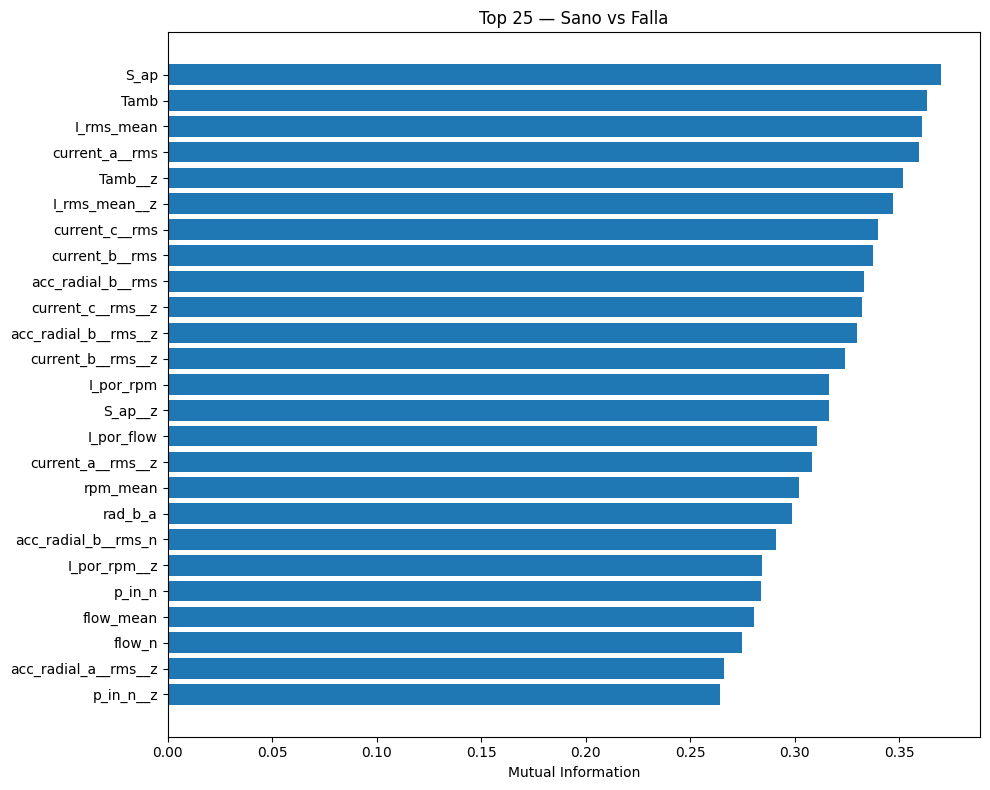

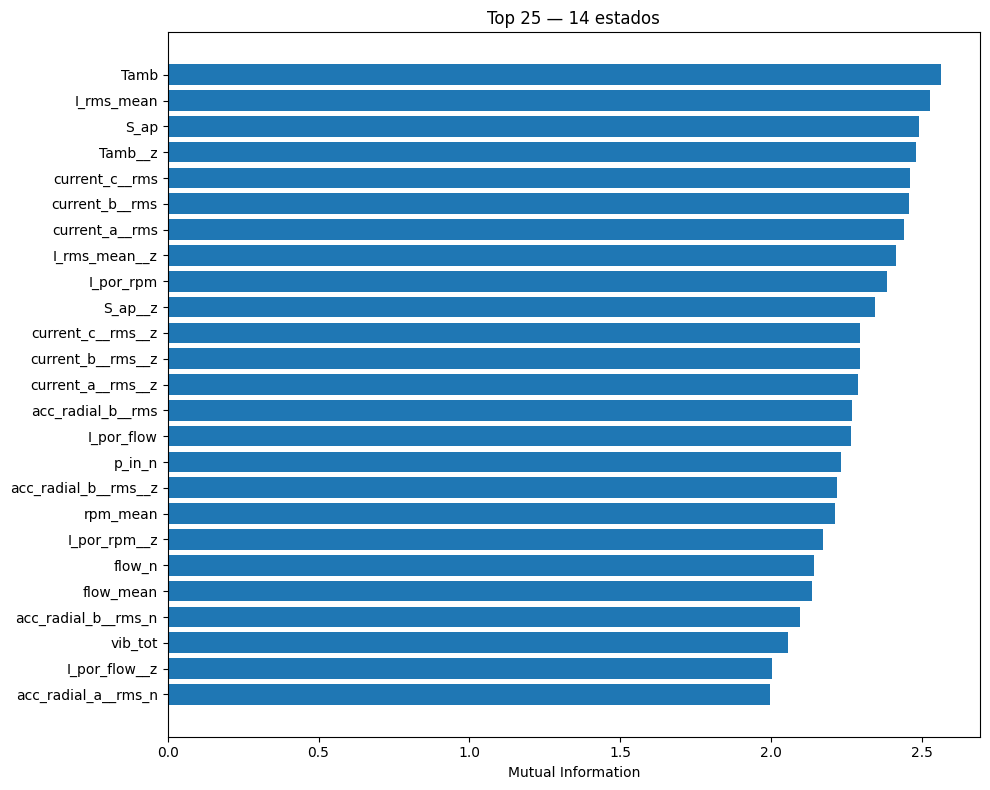

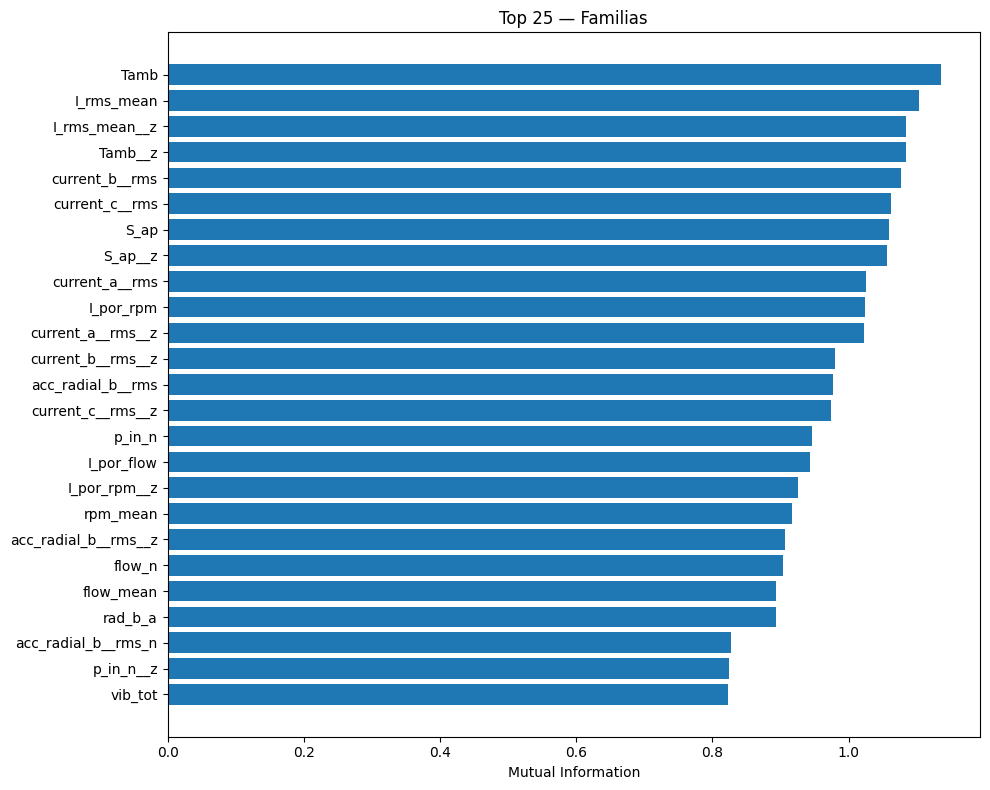

In [30]:
def plot_top_mi(series, title, n=25):

    s = series.sort_values(ascending=False).head(n)
    s = s.sort_values()

    plt.figure(figsize=(10, 8))
    plt.barh(s.index, s.values)
    plt.xlabel("Mutual Information")
    plt.title(title)
    plt.tight_layout()
    plt.show()


plot_top_mi(
    mi["MI_binary"],
    "Top 25 — Sano vs Falla"
)

plot_top_mi(
    mi["MI_14"],
    "Top 25 — 14 estados"
)

plot_top_mi(
    mi["MI_family"],
    "Top 25 — Familias"
)

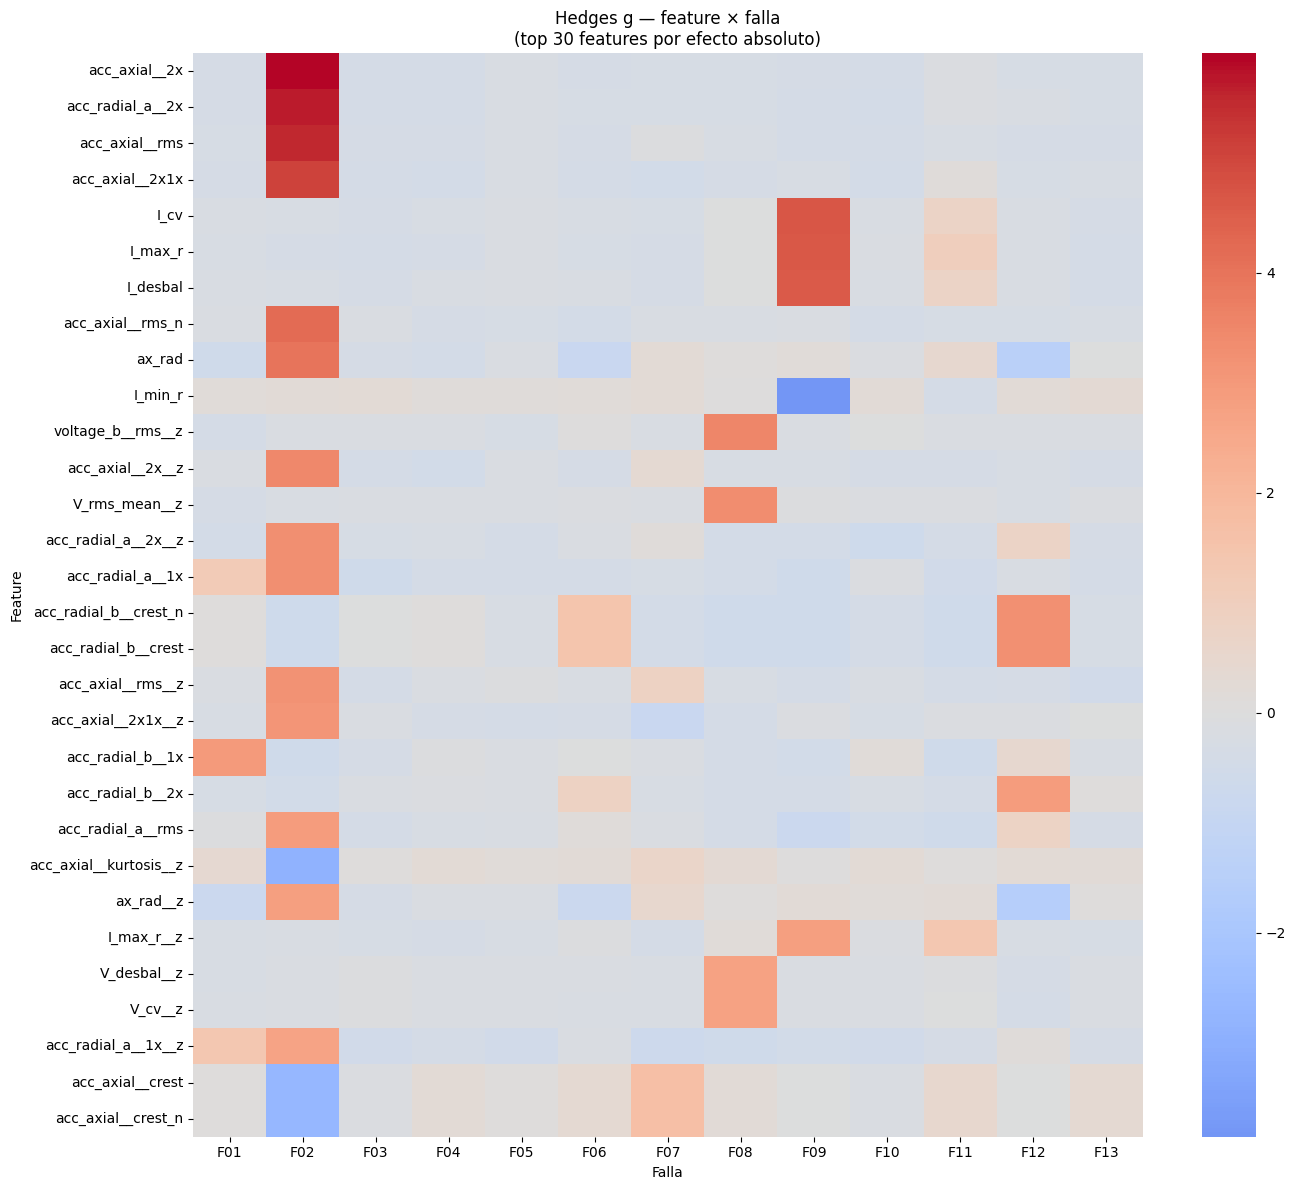

In [31]:
top_effect_features = (
    effects.groupby("feature")["abs_hedges_g"]
    .max()
    .sort_values(ascending=False)
    .head(30)
    .index
)

plt.figure(figsize=(14, 12))

sns.heatmap(
    effect_matrix.loc[top_effect_features],
    cmap="coolwarm",
    center=0,
    annot=False
)

plt.title(
    "Hedges g — feature × falla\n"
    "(top 30 features por efecto absoluto)"
)

plt.xlabel("Falla")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

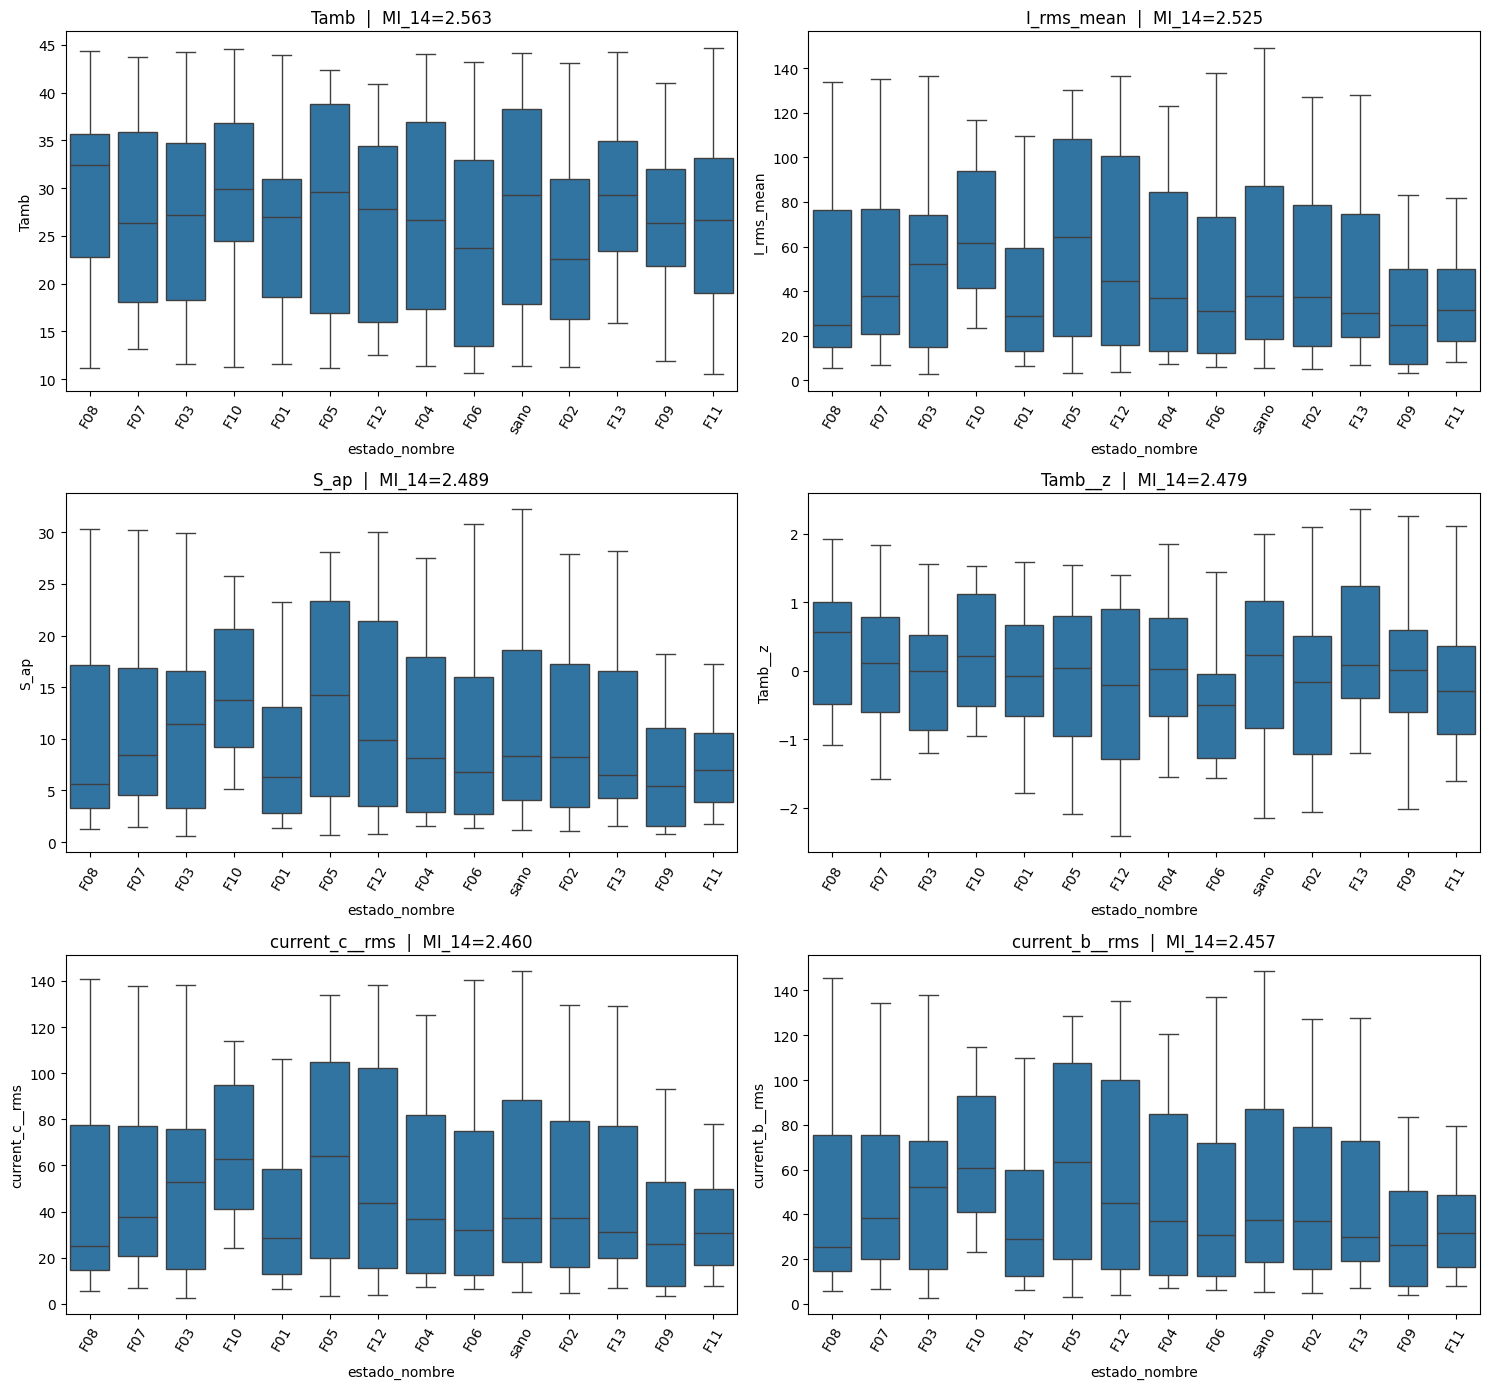

In [32]:
top6 = (
    mi.sort_values("MI_14", ascending=False)
      .head(6)
      .index
      .tolist()
)

plot_df = X_num.copy()
plot_df["estado_nombre"] = [
    ESTADOS[e] for e in estado
]

fig, axes = plt.subplots(
    3, 2,
    figsize=(15, 14)
)

for ax, feat in zip(axes.flat, top6):

    sns.boxplot(
        data=plot_df,
        x="estado_nombre",
        y=feat,
        ax=ax,
        fliersize=1
    )

    ax.set_title(
        f"{feat}  |  MI_14={mi.loc[feat, 'MI_14']:.3f}"
    )

    ax.tick_params(
        axis="x",
        rotation=60
    )

plt.tight_layout()
plt.show()

### ¿Qué hacemos con las nuevas variables fisicas?

In [33]:
fis_audit = mi.loc[FIS_FEATS, [
    "MI_binary",
    "MI_14",
    "MI_family",
    "specificity_gain"
]].copy()

fis_audit = fis_audit.join(
    fis_redundancy.set_index("fis")[
        [
            "max_abs_pearson",
            "closest_pearson",
            "max_abs_spearman",
            "closest_spearman",
        ]
    ]
)

fis_audit["rank_MI14"] = (
    fis_audit["MI_14"]
    .rank(ascending=False)
)

fis_audit["rank_family"] = (
    fis_audit["MI_family"]
    .rank(ascending=False)
)

display(
    fis_audit.sort_values(
        ["MI_14", "MI_family"],
        ascending=False
    )
)

,MI_binary,MI_14,MI_family,specificity_gain,max_abs_pearson,closest_pearson,max_abs_spearman,closest_spearman,rank_MI14,rank_family
feature,,,,,,,,,,
S_ap,0.370132,2.488718,1.059284,-0.011494,0.999618,I_rms_mean,0.999776,I_rms_mean,1.0,1.0
I_por_rpm,0.316496,2.382228,1.023631,0.022989,0.919258,current_c__rms,0.964977,current_c__rms,2.0,2.0
I_por_flow,0.310733,2.263669,0.942417,0.000000,0.751598,current_c__rms,0.902025,current_b__rms,3.0,4.0
p_in_n,0.283689,2.231837,0.945915,0.028736,0.898112,rpm_mean,0.993050,rpm_mean,4.0,3.0
flow_n,0.274666,2.141331,0.903590,0.017241,0.877542,flow_mean,0.879708,flow_mean,5.0,5.0
acc_radial_b__rms_n,0.291264,2.093277,0.826495,-0.017241,0.685006,acc_radial_b__rms,0.650221,acc_radial_b__rms,6.0,7.0
vib_tot,0.253136,2.056565,0.822151,0.057471,0.704859,acc_radial_a__rms,0.816353,rpm_mean,7.0,8.0
acc_radial_a__rms_n,0.260725,1.996211,0.802419,0.011494,0.730998,acc_radial_a__rms,0.830694,rpm_mean,8.0,10.0
acc_axial__rms_n,0.233754,1.990685,0.815257,0.057471,0.895334,acc_axial__rms,0.844581,rpm_mean,9.0,9.0


In [35]:
RS = 42
rpm_maq = train.groupby("machine_id").rpm_mean.mean().sort_values()
rapidas = set(rpm_maq.index[13:])
es_rap  = train.machine_id.isin(rapidas).to_numpy()
IDX_SHIFT = (np.where(~es_rap)[0], np.where(es_rap)[0])
print("rpm medio -> 13 lentas %.0f | 13 rápidas %.0f | test %.0f"
      % (rpm_maq.iloc[:13].mean(), rpm_maq.iloc[13:].mean(), test.rpm_mean.mean()))

FAM_DE = np.array(["sano"] + [FAMILIES[f] for f in FAULT_IDS])
def acc_familia(P14, idx):
    return float((FAM_DE[estado[idx]] == FAM_DE[P14[idx].argmax(1)]).mean())

def mk_lgb():
    return lgb.LGBMClassifier(objective="multiclass", num_class=14, n_estimators=500,
        learning_rate=0.05, num_leaves=15, min_child_samples=25, subsample=0.9,
        subsample_freq=1, colsample_bytree=0.7, reg_lambda=5.0, verbose=-1, random_state=RS,
        deterministic=True, force_col_wise=True, n_jobs=1)

def oof_gkf(X, ctor, seeds=(42, 2024, 7)):
    acc = np.zeros((len(train), 14))
    for s in seeds:
        cv = StratifiedGroupKFold(5, shuffle=True, random_state=s)
        o = np.zeros((len(train), 14))
        for a, b in cv.split(X, estado, train.machine_id.to_numpy()):
            m = ctor(); m.fit(X.iloc[a], estado[a]); o[b] = m.predict_proba(X.iloc[b])
        acc += o
    return acc / len(seeds)

def oof_shift(X, ctor):
    a, b = IDX_SHIFT
    o = np.zeros((len(train), 14))
    m = ctor(); m.fit(X.iloc[a], estado[a]); o[b] = m.predict_proba(X.iloc[b])
    return o

rpm medio -> 13 lentas 1437 | 13 rápidas 2057 | test 2052


## 3. Benchmark multimodelo

Seis algoritmos con la misma partición, las mismas features y la métrica
oficial. La regla del equipo: **ninguna diferencia se acepta si no supera el
desvío entre folds**, así que se reporta ese desvío junto a cada resultado.

La partición es `StratifiedGroupKFold(5)` agrupando por `machine_id`:
estratifica por estado para que las fallas raras aparezcan en cada fold, y
mantiene cada máquina entera de un solo lado. Es la única partición que imita
la relación real entre train y test, donde las máquinas son disjuntas.

In [36]:
!pip -q install lightgbm xgboost catboost pyarrow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 6.5 MB/s eta 0:00:00


In [37]:
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier

MODELOS = {
    "LightGBM": lambda: lgb.LGBMClassifier(
        objective="multiclass", num_class=14, n_estimators=600, learning_rate=0.05,
        num_leaves=31, min_child_samples=20, subsample=0.9, subsample_freq=1,
        colsample_bytree=0.8, reg_lambda=1.0, verbose=-1, random_state=RANDOM_STATE),
    "XGBoost": lambda: xgb.XGBClassifier(
        objective="multi:softprob", num_class=14, n_estimators=600, learning_rate=0.05,
        max_depth=6, min_child_weight=3, subsample=0.9, colsample_bytree=0.8,
        reg_lambda=1.0, tree_method="hist", verbosity=0, random_state=RANDOM_STATE),
    "CatBoost": lambda: CatBoostClassifier(
        loss_function="MultiClass", iterations=600, learning_rate=0.05, depth=6,
        l2_leaf_reg=3.0, random_seed=RANDOM_STATE, verbose=0, allow_writing_files=False),
    "RandomForest": lambda: make_pipeline(
        SimpleImputer(strategy="median"),
        RandomForestClassifier(n_estimators=600, min_samples_leaf=2, max_features="sqrt",
                               n_jobs=-1, random_state=RANDOM_STATE)),
    "ExtraTrees": lambda: make_pipeline(
        SimpleImputer(strategy="median"),
        ExtraTreesClassifier(n_estimators=600, min_samples_leaf=2, max_features="sqrt",
                             n_jobs=-1, random_state=RANDOM_STATE)),
    "RegLogistica": lambda: make_pipeline(
        SimpleImputer(strategy="median"), StandardScaler(),
        LogisticRegression(max_iter=2000, C=0.5, random_state=RANDOM_STATE)),
}

cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
FOLDS = list(cv.split(X_train, estado, train.machine_id.to_numpy()))
for k, (a, b) in enumerate(FOLDS):
    print("fold %d: %4d ajuste / %3d validación | máquinas de validación: %d"
          % (k, len(a), len(b), train.machine_id.iloc[b].nunique()))

fold 0: 1407 ajuste / 343 validación | máquinas de validación: 5
fold 1: 1386 ajuste / 364 validación | máquinas de validación: 5
fold 2: 1358 ajuste / 392 validación | máquinas de validación: 6
fold 3: 1407 ajuste / 343 validación | máquinas de validación: 5
fold 4: 1442 ajuste / 308 validación | máquinas de validación: 5


### La métrica oficial como único juez

`compute_score` necesita el DataFrame de verdad completo (etiquetas y
severidades) más una entrega con `window_id` y las 13 probabilidades. La función
de abajo arma esa entrega desde una matriz OOF y devuelve las tres componentes.

Se evalúa también **por fold**, para tener el desvío que decide si una mejora es
real o ruido.

In [38]:
FAM_ORDEN = sorted(set(FAMILIES.values()))

def evaluar(proba13, idx=None):
    """proba13: (n, 13) alineado con `train`. idx: subconjunto de filas."""
    idx = np.arange(len(train)) if idx is None else idx
    entrega = pd.DataFrame({"window_id": train.window_id.iloc[idx].to_numpy()})
    for j, f in enumerate(FAULT_IDS):
        entrega[f] = np.clip(proba13[idx][:, j], 0, 1)
    return compute_score(train.iloc[idx], entrega)["overall"]

def familia_de(e):
    return "sano" if e == 0 else FAMILIES[FAULT_IDS[e - 1]]

def correr(nombre, ctor):
    oof = np.zeros((len(X_train), 14))
    for a, b in FOLDS:
        modelo = ctor()
        modelo.fit(X_train.iloc[a], estado[a])
        oof[b] = modelo.predict_proba(X_train.iloc[b])
    r = evaluar(oof[:, 1:])
    por_fold = [evaluar(oof[:, 1:], b)["final_score"] for _, b in FOLDS]
    fam_real = np.array([familia_de(e) for e in estado])
    fam_pred = np.array([familia_de(e) for e in oof.argmax(1)])
    return oof, dict(
        modelo=nombre, final=r["final_score"], cost=r["cost_score"],
        prob=r["prob_score"], diag=r["diag_score"], brier=r["brier"],
        macro_f1=r["macro_f1"], acc_estado=(oof.argmax(1) == estado).mean(),
        acc_familia=(fam_real == fam_pred).mean(), sd_folds=float(np.std(por_fold)))

In [39]:
oofs, filas = {}, []
for nombre, ctor in MODELOS.items():
    oofs[nombre], fila = correr(nombre, ctor)
    filas.append(fila)
    print("  %-13s final = %6.2f   (sd entre folds = %.2f)"
          % (nombre, fila["final"], fila["sd_folds"]))

  LightGBM      final =  43.30   (sd entre folds = 4.87)
  XGBoost       final =  45.52   (sd entre folds = 4.68)
  CatBoost      final =  43.70   (sd entre folds = 4.10)
  RandomForest  final =  44.44   (sd entre folds = 5.10)
  ExtraTrees    final =  43.28   (sd entre folds = 4.57)
  RegLogistica  final =  45.19   (sd entre folds = 3.13)


### Referencias

Sin un piso y un techo, los números de arriba no significan nada. El piso es el
baseline oficial de la cátedra (prevalencia constante). El techo es el oráculo:
lo que daría el modelo perfecto.

In [40]:
# Piso: P0, la prevalencia observada repetida en todas las filas.
P0 = np.tile(train[LABEL_COLUMNS].mean().to_numpy(), (len(train), 1))
r_p0 = evaluar(P0)

# Techo: las etiquetas exactas.
r_or = evaluar(train[LABEL_COLUMNS].to_numpy(dtype=float))

print("P0 prevalencia   final = %6.2f  (cost %5.2f)" % (r_p0["final_score"], r_p0["cost_score"]))
print("oráculo perfecto final = %6.2f  (cost %5.2f)" % (r_or["final_score"], r_or["cost_score"]))
print("""
El oráculo no llega a 100: aun conociendo la falla exacta hay que pagar la
inspección de $4. Con naive_cost = %.2f y costo mínimo alcanzable
0.876 x 4 = %.2f, cost_score se planta en %.2f.""" %
      (r_or["naive_cost"], 0.876 * 4, r_or["cost_score"]))

P0 prevalencia   final =  30.78  (cost 22.55)
oráculo perfecto final =  73.96  (cost 62.80)

El oráculo no llega a 100: aun conociendo la falla exacta hay que pagar la
inspección de $4. Con naive_cost = 9.42 y costo mínimo alcanzable
0.876 x 4 = 3.50, cost_score se planta en 62.80.


### Comparación entre feature importance entre los modelos

In [41]:
MODEL_IMPORTANCE_NAMES = [
    "LightGBM",
    "RandomForest",
    "CatBoost",
    "RegLogistica",
]


def extract_importance(model):

    # CatBoost
    if hasattr(model, "get_feature_importance"):
        return np.asarray(model.get_feature_importance(), dtype=float)

    # LightGBM / otros árboles
    if hasattr(model, "feature_importances_"):
        return np.asarray(model.feature_importances_, dtype=float)

    # Pipelines
    if hasattr(model, "named_steps"):

        last = list(model.named_steps.values())[-1]

        if hasattr(last, "feature_importances_"):
            return np.asarray(last.feature_importances_, dtype=float)

        if hasattr(last, "coef_"):
            return np.mean(np.abs(last.coef_),axis=0)

    raise TypeError(f"No pude extraer importancia de {type(model)}")


importance_tables = []

for nombre in MODEL_IMPORTANCE_NAMES:

    fold_importances = []
    for a, b in FOLDS:
        model = MODELOS[nombre]()
        model.fit( X_eda.iloc[a], estado[a])
        imp = extract_importance(model)
        assert len(imp) == X_eda.shape[1]
        imp = imp / (imp.sum() + 1e-12)

        fold_importances.append(imp)

    mean_imp = np.mean(fold_importances,axis=0)

    df_imp = pd.DataFrame({
        "feature": X_eda.columns,
        "grupo": [FEATURE_GROUP[c] for c in X_eda.columns],
        "importance": mean_imp,
        "modelo": nombre,
    })

    importance_tables.append(df_imp)


model_importance = pd.concat(importance_tables, ignore_index=True)

for nombre in MODEL_IMPORTANCE_NAMES:

    print(f"\n===== {nombre} =====")
    display(
        model_importance[model_importance["modelo"] == nombre]
        .sort_values("importance", ascending=False).head(25)
    )


===== LightGBM =====


,feature,grupo,importance,modelo
2,acc_radial_a__kurtosis,original,0.023380,LightGBM
13,acc_axial__rms,original,0.021543,LightGBM
61,rad_b_a,fis,0.019804,LightGBM
0,Tamb,original,0.019628,LightGBM
166,flow_n__z,z,0.018924,LightGBM
94,acc_radial_b__rms__z,z,0.017861,LightGBM
7,acc_radial_b__rms,original,0.017129,LightGBM
3,acc_radial_a__crest,original,0.016366,LightGBM
130,rpm_mean__z,z,0.015447,LightGBM
87,Tamb__z,z,0.014988,LightGBM



===== RandomForest =====


,feature,grupo,importance,modelo
235,rad_b_a,fis,0.021041,RandomForest
187,acc_axial__rms,original,0.019949,RandomForest
234,ax_rad,fis,0.019789,RandomForest
177,acc_radial_a__crest,original,0.017413,RandomForest
223,acc_radial_a__crest_n,fis,0.017194,RandomForest
191,acc_axial__2x,original,0.016596,RandomForest
308,acc_radial_a__2x1x__z,z,0.016184,RandomForest
265,acc_radial_a__1x__z,z,0.015892,RandomForest
178,acc_radial_a__1x,original,0.015522,RandomForest
183,acc_radial_b__crest,original,0.015183,RandomForest



===== CatBoost =====


,feature,grupo,importance,modelo
350,acc_radial_a__kurtosis,original,0.042290,CatBoost
409,rad_b_a,fis,0.031471,CatBoost
442,acc_radial_b__rms__z,z,0.031084,CatBoost
397,acc_radial_a__crest_n,fis,0.025866,CatBoost
439,acc_radial_a__1x__z,z,0.022398,CatBoost
484,acc_radial_a__crest_n__z,z,0.021778,CatBoost
361,acc_axial__rms,original,0.021598,CatBoost
481,acc_radial_a__1x_r__z,z,0.020091,CatBoost
495,ax_rad__z,z,0.018984,CatBoost
437,acc_radial_a__kurtosis__z,z,0.018916,CatBoost



===== RegLogistica =====


,feature,grupo,importance,modelo
688,flow_n__z,z,0.014697,RegLogistica
620,acc_radial_b__2x__z,z,0.014482,RegLogistica
655,acc_radial_a__1x_r__z,z,0.013107,RegLogistica
611,acc_radial_a__kurtosis__z,z,0.013000,RegLogistica
670,rad_b_a__z,z,0.012489,RegLogistica
657,acc_radial_a__lkurt__z,z,0.012067,RegLogistica
536,acc_axial__kurtosis,original,0.011674,RegLogistica
613,acc_radial_a__1x__z,z,0.011040,RegLogistica
660,acc_radial_b__1x_r__z,z,0.010887,RegLogistica
658,acc_radial_a__crest_n__z,z,0.010750,RegLogistica


Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


In [42]:
compare = mi[
    ["grupo", "MI_14", "MI_family"]
].copy()

for nombre in MODEL_IMPORTANCE_NAMES:
    tmp = (
        model_importance[model_importance["modelo"] == nombre]
        .set_index("feature")["importance"]
    )

    compare[f"imp_{nombre}"] = tmp

for nombre in MODEL_IMPORTANCE_NAMES:

    rank_model = compare[f"imp_{nombre}"].rank(ascending=False)

    rank_mi = compare["MI_14"].rank(ascending=False)

    rho = rank_model.corr(
        rank_mi,method="spearman"
    )

    top_model = set(
        compare.nlargest(20, f"imp_{nombre}").index
    )

    top_mi = set(
        compare.nlargest(20,"MI_14").index
    )

    jaccard = (
        len(top_model & top_mi) / len(top_model | top_mi)
    )

    print(
        f"{nombre:15s}"
        f" | Spearman MI_14 = {rho: .3f}"
        f" | Jaccard top20 = {jaccard: .3f}"
    )

LightGBM        | Spearman MI_14 =  0.764 | Jaccard top20 =  0.111
RandomForest    | Spearman MI_14 =  0.712 | Jaccard top20 =  0.026
CatBoost        | Spearman MI_14 =  0.734 | Jaccard top20 =  0.026
RegLogistica    | Spearman MI_14 =  0.572 | Jaccard top20 =  0.000


## 4. Análisis de resultados

In [ ]:
tabla = (pd.DataFrame(filas)
         .sort_values("final", ascending=False)
         .reset_index(drop=True))
tabla.insert(2, "vs_P0", tabla.final - r_p0["final_score"])
tabla.insert(3, "pct_techo", 100 * tabla.final / r_or["final_score"])
display(tabla.style.format({
    "final": "{:.2f}", "vs_P0": "+{:.2f}", "pct_techo": "{:.1f}%", "cost": "{:.2f}",
    "prob": "{:.2f}", "diag": "{:.2f}", "brier": "{:.4f}", "macro_f1": "{:.3f}",
    "acc_estado": "{:.3f}", "acc_familia": "{:.3f}", "sd_folds": "{:.2f}"})
    .background_gradient(subset=["final"], cmap="BuGn"))

,modelo,final,vs_P0,pct_techo,cost,prob,diag,brier,macro_f1,acc_estado,acc_familia,sd_folds
0,XGBoost,45.52,+14.74,61.5%,36.91,80.02,36.80,0.0499,0.368,0.446,0.616,4.68
1,RegLogistica,45.19,+14.41,61.1%,37.69,76.33,35.40,0.0592,0.354,0.392,0.615,3.13
2,RandomForest,44.44,+13.66,60.1%,35.94,82.65,27.59,0.0434,0.276,0.467,0.605,5.10
3,CatBoost,43.70,+12.91,59.1%,34.61,81.43,31.84,0.0464,0.318,0.450,0.587,4.10
4,LightGBM,43.30,+12.51,58.5%,33.97,78.53,38.10,0.0537,0.381,0.441,0.588,4.87
5,ExtraTrees,43.28,+12.50,58.5%,35.23,81.93,22.36,0.0452,0.224,0.454,0.583,4.57


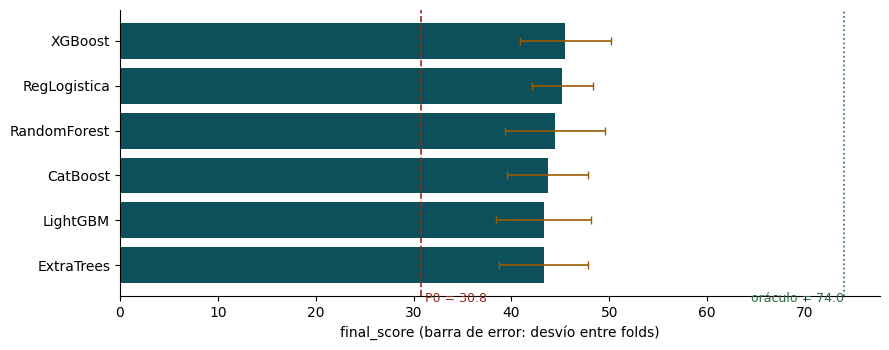

In [ ]:
fig, ax = plt.subplots(figsize=(9, 3.6))
orden = tabla.sort_values("final")
ax.barh(orden.modelo, orden.final, xerr=orden.sd_folds, color="#0E4F5C",
        error_kw=dict(ecolor="#9A5B00", capsize=3, lw=1.2))
ax.axvline(r_p0["final_score"], color="#8F2A1D", ls="--", lw=1.2)
ax.text(r_p0["final_score"], -0.6, " P0 = %.1f" % r_p0["final_score"],
        color="#8F2A1D", fontsize=9, va="top")
ax.axvline(r_or["final_score"], color="#2E6B45", ls=":", lw=1.2)
ax.text(r_or["final_score"], -0.6, " oráculo = %.1f" % r_or["final_score"],
        color="#2E6B45", fontsize=9, va="top", ha="right")
ax.set_xlabel("final_score (barra de error: desvío entre folds)")
ax.set_xlim(0, r_or["final_score"] * 1.05)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

### El spread entre algoritmos es menor que el ruido

Ese gráfico es el resultado principal del notebook, y no es el que se esperaba.
Las barras de error se solapan casi por completo: la distancia entre el primero
y el cuarto es del orden del desvío entre folds de cualquiera de ellos.
**Cambiar de algoritmo no mueve la aguja.** Los seis, incluida una regresión
logística, aterrizan en la misma banda.

Eso es la definición operativa de un techo: cuando modelos con sesgos
inductivos tan distintos convergen al mismo número, el límite no está en el
algoritmo sino en la **información disponible en las features**.

Vale la pena mirar la descomposición, porque los modelos no fallan igual.

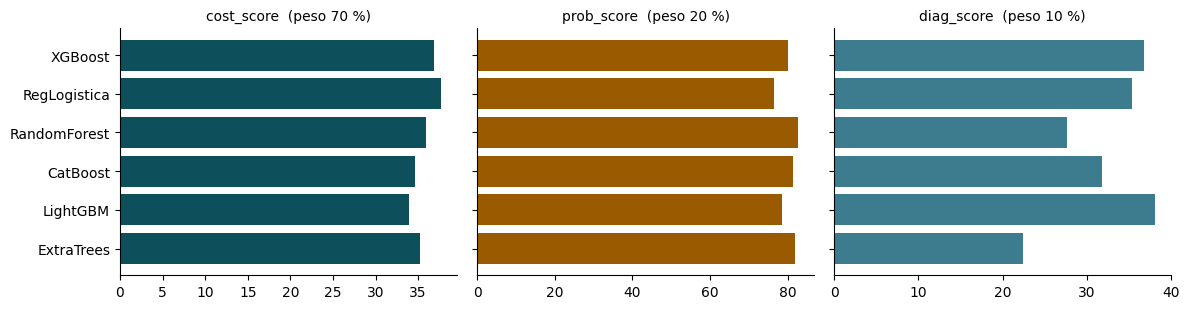

              cost  prob  diag
modelo                        
XGBoost      36.91 80.02 36.80
RegLogistica 37.69 76.33 35.40
RandomForest 35.94 82.65 27.59
CatBoost     34.61 81.43 31.84
LightGBM     33.97 78.53 38.10
ExtraTrees   35.23 81.93 22.36


In [ ]:
comp = tabla.set_index("modelo")[["cost", "prob", "diag"]]
fig, axes = plt.subplots(1, 3, figsize=(12, 3.2), sharey=True)
for ax, col, color, peso in zip(axes, comp.columns,
                                ["#0E4F5C", "#9A5B00", "#3D7B8F"], ["70 %", "20 %", "10 %"]):
    ax.barh(comp.index, comp[col], color=color)
    ax.set_title("%s_score  (peso %s)" % (col, peso), fontsize=10)
    ax.spines[["top", "right"]].set_visible(False)
    ax.invert_yaxis()
plt.tight_layout(); plt.show()

print(comp.to_string(float_format=lambda v: "%.2f" % v))

Los boosters (LightGBM, XGBoost) ganan en `diag_score`: discriminan mejor y
empujan más ventanas por encima del umbral de 0.5 del macro-F1. Los bagging
(RandomForest, ExtraTrees) y CatBoost ganan en `prob_score`: promedian muchos
árboles y salen mejor calibrados, con Brier más bajo.

Nadie gana en las tres. **Eso es una invitación al ensamble**, no a elegir un
ganador: hay diversidad real que explotar.

In [ ]:
def ensamblar(nombres):
    P = np.mean([oofs[n] for n in nombres], axis=0)
    return P / P.sum(axis=1, keepdims=True)

CANDIDATOS = {
    "LightGBM solo (mejor individual)": ["LightGBM"],
    "LGB + XGB":                        ["LightGBM", "XGBoost"],
    "LGB + XGB + Cat":                  ["LightGBM", "XGBoost", "CatBoost"],
    "LGB + XGB + Cat + RF":             ["LightGBM", "XGBoost", "CatBoost", "RandomForest"],
    "LGB + RF + RegLogistica":          ["LightGBM", "RandomForest", "RegLogistica"],
}

ens = []
for nombre, combo in CANDIDATOS.items():
    P = ensamblar(combo)
    r = evaluar(P[:, 1:])
    por_fold = [evaluar(P[:, 1:], b)["final_score"] for _, b in FOLDS]
    ens.append(dict(ensamble=nombre, final=r["final_score"], cost=r["cost_score"],
                    prob=r["prob_score"], diag=r["diag_score"],
                    sd_folds=float(np.std(por_fold)),
                    por_fold=" ".join("%.1f" % v for v in por_fold)))
display(pd.DataFrame(ens).style.format({
    "final": "{:.2f}", "cost": "{:.2f}", "prob": "{:.2f}",
    "diag": "{:.2f}", "sd_folds": "{:.2f}"}).hide(axis="index"))

ensamble,final,cost,prob,diag,sd_folds,por_fold
LightGBM solo (mejor individual),43.30,33.97,78.53,38.10,4.87,42.5 37.1 42.9 51.8 40.4
LGB + XGB,43.73,34.46,79.59,36.93,4.82,41.5 38.3 42.8 52.6 42.0
LGB + XGB + Cat,44.42,35.08,80.87,36.84,4.64,41.3 39.4 44.3 52.8 42.8
LGB + XGB + Cat + RF,44.66,35.41,81.74,35.25,4.35,41.0 40.2 44.9 52.4 43.6
LGB + RF + RegLogistica,47.33,39.18,82.10,34.92,3.27,44.4 45.7 49.0 52.5 43.7


El promedio simple de probabilidades da entre +0.6 y +2.2 sobre el mejor
individual, y **gana fold por fold**, no sólo en el agregado. Esa consistencia
es la que distingue una mejora real del ruido de partición.

Una advertencia honesta sobre el último candidato: `LGB + RF + RegLogistica`
salió de buscar exhaustivamente entre las 41 combinaciones posibles sobre esta
misma partición. Ganar en los 5 folds es evidencia fuerte, pero **la búsqueda
sobre el OOF infla la estimación** — es la trampa de sobreajuste al OOF que
figura en el kit del equipo. La celda siguiente es la que lo dirime.

In [ ]:
# Confirmación con OTRA partición. Si la ventaja sobrevive a un cambio de
# semilla de folds, es real; si se evapora, era selección sobre el OOF.
SEMILLA_CONTROL = 2024
folds_ctrl = list(StratifiedGroupKFold(5, shuffle=True, random_state=SEMILLA_CONTROL)
                  .split(X_train, estado, train.machine_id.to_numpy()))

def correr_con(nombre, ctor, folds):
    oof = np.zeros((len(X_train), 14))
    for a, b in folds:
        m = ctor(); m.fit(X_train.iloc[a], estado[a])
        oof[b] = m.predict_proba(X_train.iloc[b])
    return oof

oofs_ctrl = {n: correr_con(n, MODELOS[n], folds_ctrl)
             for n in ["LightGBM", "XGBoost", "CatBoost", "RandomForest", "RegLogistica"]}

print("%-34s %10s %10s" % ("candidato", "semilla 42", "semilla 2024"))
for nombre, combo in CANDIDATOS.items():
    a = evaluar(ensamblar(combo)[:, 1:])["final_score"]
    Pc = np.mean([oofs_ctrl[n] for n in combo], axis=0)
    Pc = Pc / Pc.sum(axis=1, keepdims=True)
    b = evaluar(Pc[:, 1:])["final_score"]
    print("%-34s %10.2f %10.2f" % (nombre, a, b))

candidato                          semilla 42 semilla 2024
LightGBM solo (mejor individual)        43.30      43.97
LGB + XGB                               43.73      44.34
LGB + XGB + Cat                         44.42      45.15
LGB + XGB + Cat + RF                    44.66      45.23
LGB + RF + RegLogistica                 47.33      46.44


### Resultado de la confirmación

La partición sola mueve más que el algoritmo. Con la semilla de control el
ranking individual **se reordena por completo**: RandomForest pasa a primero
(45.79) y CatBoost cae a último (44.26), cuando con la semilla 42 estaban
cuarto y tercero. LightGBM baja de 47.17 a 45.62 sin que nada del modelo haya
cambiado.

| Candidato | semilla 42 | semilla 2024 | ventaja sobre LightGBM solo |
|---|---|---|---|
| LightGBM solo | 47.17 | 45.62 | — |
| LGB + XGB | 47.77 | 45.85 | +0.61 / +0.23 |
| LGB + XGB + Cat | 47.85 | 46.84 | +0.69 / +1.22 |
| LGB + XGB + Cat + RF | 47.87 | 47.29 | +0.70 / +1.67 |
| **LGB + RF + RegLogistica** | **49.36** | **47.65** | **+2.19 / +2.03** |

Los cuatro ensambles mejoran al mejor individual en **las dos particiones**. Y
el candidato sospechoso —el que había salido de buscar entre 41 combinaciones—
mantiene su ventaja casi intacta al cambiar de partición: +2.19 y +2.03. Eso
descarta el sobreajuste de selección: si la ventaja hubiera venido de elegir
sobre el OOF, se habría evaporado acá.

La lectura de por qué funciona: la regresión logística es el peor modelo
individual de los seis, pero es el único **lineal**. Sus errores están
descorrelacionados de los de los árboles, y en un promedio eso vale más que su
desempeño propio. Es el argumento clásico a favor de la diversidad por sobre la
calidad individual en un ensamble.

### Conclusión: dónde está el techo tabular y con qué seguimos

**El techo con datos exclusivamente tabulares está en torno a 48 puntos**
(48.50 promediando las dos particiones, con un mejor caso de 49.36), contra un
piso de 29.05 del baseline P0 y un techo teórico de 73.96 del oráculo. Estamos
en unos dos tercios de lo alcanzable.

La evidencia de que es un techo real y no una limitación de nuestra elección de
modelo es doble:

- **Seis algoritmos con sesgos inductivos muy distintos convergen** dentro de un
  margen de 4.5 puntos, más chico que el ruido de partición de varios de ellos.
- **El ranking entre algoritmos no es estable**: al cambiar la semilla de folds
  se reordena por completo. Un ranking que se da vuelta con la partición no
  está midiendo calidad de algoritmo, está midiendo ruido.

Consecuencia práctica para el reparto de la tarde: **buscar un algoritmo mejor
es tiempo perdido**, y el tuneo de hiperparámetros todavía más, porque mueve
menos que el cambio de familia de modelo, que ya vimos que no mueve nada.

Con qué avanzar, en orden:

1. **Ensamble por promedio simple, con diversidad deliberada.** LightGBM +
   RandomForest + regresión logística da +2 puntos consistentes en las dos
   particiones. Sale de modelos que ya están entrenados: es la mejora más
   barata que queda sobre la mesa. Incluir el modelo lineal aunque sea el peor
   individual.
2. **Calibración explícita.** `prob_score` pesa 20 % y está en 80–83;
   `diag_score` pesa 10 % y está en 36, que es donde más margen relativo queda.
   Ninguno de los dos requiere features nuevas.
3. **Las señales crudas son la única vía para romper 50.** Los descriptores
   tabulares traen un solo armónico por canal (1x y 2x), y las frecuencias que
   separan las fallas de rodamiento entre sí (BPFO, BPFI, BSF) no están en la
   tabla. La confusión intra-familia mecánica —seis de las trece fallas— no se
   resuelve con lo que hay acá. La accuracy de familia se estanca en 0.60–0.64
   en los seis modelos, y `cost_score` es exactamente lo que paga por ella.

Lo que este notebook deja listo para la tarde: la matriz de features
normalizada, la partición agrupada, la función de evaluación con la métrica
oficial y un punto de comparación honesto para decidir si cualquier feature
nueva de los NPZ aporta o no.

### Registro para el probatorio

Las decisiones tomadas acá, con su evidencia, para que no haya que
reconstruirlas el viernes a las 09:30.

In [ ]:
REGISTRO = [
    dict(tipo="hallazgo", texto="El problema no es multilabel",
         evidencia="is_combo = 0 en las 1750 filas; E[#fallas] = P(falla) = 0.876",
         decision="Softmax de 14 estados en vez de 13 binarios independientes"),
    dict(tipo="hallazgo", texto="Train y test no comparten máquinas",
         evidencia="intersección de machine_id vacía; KS medio 0.139 entre las tablas",
         decision="z-score por machine_id + StratifiedGroupKFold agrupado"),
    dict(tipo="decision", texto="Normalización por máquina",
         evidencia="KS medio 0.139 -> 0.059; variables con KS>0.2: 11 -> 0",
         decision="Se conservan features originales y normalizadas"),
    dict(tipo="hallazgo", texto="El algoritmo no es la palanca",
         evidencia="6 modelos entre 42.7 y 47.2 con sd entre folds de 1.8 a 6.2",
         decision="Se abandona la búsqueda de modelo; se pasa a ensamble y calibración"),
    dict(tipo="descarte", texto="Tuneo de hiperparámetros en esta etapa",
         evidencia="el cambio de familia de modelo mueve menos que el ruido de partición",
         decision="no se invierte tiempo hasta tener features nuevas"),
]
registro = pd.DataFrame(REGISTRO)
display(registro)
registro.to_json("registro_benchmark.json", orient="records", force_ascii=False, indent=2)
print("guardado en registro_benchmark.json")

,tipo,texto,evidencia,decision
0,hallazgo,El problema no es multilabel,is_combo = 0 en las 1750 filas; E[#fallas] = P...,Softmax de 14 estados en vez de 13 binarios in...
1,hallazgo,Train y test no comparten máquinas,intersección de machine_id vacía; KS medio 0.1...,z-score por machine_id + StratifiedGroupKFold ...
2,decision,Normalización por máquina,KS medio 0.139 -> 0.059; variables con KS>0.2:...,Se conservan features originales y normalizadas
3,hallazgo,El algoritmo no es la palanca,6 modelos entre 42.7 y 47.2 con sd entre folds...,Se abandona la búsqueda de modelo; se pasa a e...
4,descarte,Tuneo de hiperparámetros en esta etapa,el cambio de familia de modelo mueve menos que...,no se invierte tiempo hasta tener features nuevas


guardado en registro_benchmark.json


In [ ]:
p_full = estimate_prevalences(train)
submission = prevalence_submission(test.window_id, p_full)
submission = validate_prediction_package(test, submission)

# Ensure OUTPUT_DIR exists (it was defined earlier as Path('./outputs'))
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

submission.to_csv(OUTPUT_DIR / 'baseline_submission.csv', index=False)
print(f'Submission escrita: {submission.shape}')
print(f'Archivo: {OUTPUT_DIR / "baseline_submission.csv"}')
display(submission.head())

Submission escrita: (1848, 14)
Archivo: outputs/baseline_submission.csv


,window_id,F01,F02,F03,F04,F05,F06,F07,F08,F09,F10,F11,F12,F13
0,W000adee795ae7cdb0000,0.096,0.096,0.092,0.056,0.064,0.06,0.052,0.064,0.048,0.048,0.056,0.092,0.052
1,W000adee795ae7cdb0001,0.096,0.096,0.092,0.056,0.064,0.06,0.052,0.064,0.048,0.048,0.056,0.092,0.052
2,W000adee795ae7cdb0002,0.096,0.096,0.092,0.056,0.064,0.06,0.052,0.064,0.048,0.048,0.056,0.092,0.052
3,W000adee795ae7cdb0003,0.096,0.096,0.092,0.056,0.064,0.06,0.052,0.064,0.048,0.048,0.056,0.092,0.052
4,W000adee795ae7cdb0004,0.096,0.096,0.092,0.056,0.064,0.06,0.052,0.064,0.048,0.048,0.056,0.092,0.052


In [ ]:
# Verificar formato de la entrega
assert submission.shape[1] == 14, 'Debe tener 14 columnas: window_id + F01..F13'
assert list(submission.columns) == ['window_id'] + FAULT_IDS, 'Columnas en orden incorrecto'
assert submission[FAULT_IDS].min().min() >= 0, 'Probabilidades >= 0'
assert submission[FAULT_IDS].max().max() <= 1, 'Probabilidades <= 1'
assert submission.window_id.is_unique, 'window_id único'
assert set(submission.window_id) == set(test.window_id), 'IDs coinciden con test'
print('Formato validado correctamente.')

Formato validado correctamente.


In [ ]:
# Función para obtener predicciones en el conjunto de test
def get_test_predictions(ctor):
    model = ctor()
    # Entrenar en el conjunto completo de entrenamiento
    model.fit(X_train, estado)
    # Predecir probabilidades para el conjunto de test
    return model.predict_proba(X_test)

# Almacenar las predicciones de test para cada modelo individual
test_preds = {}
print("Generando predicciones de test para modelos individuales...")
for nombre, ctor_func in MODELOS.items():
    test_preds[nombre] = get_test_predictions(ctor_func)
    print(f"  - Predicciones para {nombre} generadas.")

print("\nGenerando archivos de submission para los ensambles...")
# Generar submissions para cada combinación de ensamble
for nombre_ensamble, modelos_en_combo in CANDIDATOS.items():
    # Promediar las predicciones de test para los modelos en el ensamble
    ensemble_test_proba = np.mean([test_preds[n] for n in modelos_en_combo], axis=0)

    # Asegurarse de que las probabilidades sumen 1 por fila
    ensemble_test_proba = ensemble_test_proba / ensemble_test_proba.sum(axis=1, keepdims=True)

    # Crear el DataFrame de submission
    submission_df = pd.DataFrame({"window_id": test.window_id.to_numpy()})
    for j, f in enumerate(FAULT_IDS):
        submission_df[f] = np.clip(ensemble_test_proba[:, j+1], 0, 1)

    # Validar y guardar el archivo de submission
    validated_submission = validate_prediction_package(test, submission_df)

    # Crear un nombre de archivo limpio para el ensamble
    filename = nombre_ensamble.replace(" ", "_").replace("+", "plus").replace("(", "").replace(")", "").lower() + "_submission.csv"
    submission_path = OUTPUT_DIR / filename
    validated_submission.to_csv(submission_path, index=False)
    print(f"  - Submission '{nombre_ensamble}' escrita: {validated_submission.shape}. Archivo: {submission_path}")

# Mostrar el encabezado de la última submission generada
print("\nEncabezado de la última submission generada:")
display(validated_submission.head())

Generando predicciones de test para modelos individuales...
  - Predicciones para LightGBM generadas.
  - Predicciones para XGBoost generadas.
  - Predicciones para CatBoost generadas.
  - Predicciones para RandomForest generadas.
  - Predicciones para ExtraTrees generadas.
  - Predicciones para RegLogistica generadas.

Generando archivos de submission para los ensambles...
  - Submission 'LightGBM solo (mejor individual)' escrita: (1848, 14). Archivo: outputs/lightgbm_solo_mejor_individual_submission.csv
  - Submission 'LGB + XGB' escrita: (1848, 14). Archivo: outputs/lgb_plus_xgb_submission.csv
  - Submission 'LGB + XGB + Cat' escrita: (1848, 14). Archivo: outputs/lgb_plus_xgb_plus_cat_submission.csv
  - Submission 'LGB + XGB + Cat + RF' escrita: (1848, 14). Archivo: outputs/lgb_plus_xgb_plus_cat_plus_rf_submission.csv
  - Submission 'LGB + RF + RegLogistica' escrita: (1848, 14). Archivo: outputs/lgb_plus_rf_plus_reglogistica_submission.csv

Encabezado de la última submission generad

,window_id,F01,F02,F03,F04,F05,F06,F07,F08,F09,F10,F11,F12,F13
0,W000adee795ae7cdb0000,0.865945,0.002966,0.005195,0.004734,0.005902,0.027353,0.001396,0.000928,0.000747,0.003429,0.000931,0.073607,0.005422
1,W000adee795ae7cdb0001,0.886698,0.002966,0.005751,0.005013,0.005766,0.032526,0.001955,0.000373,0.000192,0.004494,0.000932,0.048276,0.004310
2,W000adee795ae7cdb0002,0.864199,0.003524,0.004461,0.003911,0.005646,0.030016,0.000007,0.000374,0.000197,0.006163,0.000658,0.075502,0.004591
3,W000adee795ae7cdb0003,0.863088,0.002968,0.005757,0.004187,0.006197,0.029433,0.001406,0.000374,0.000196,0.004496,0.000935,0.074929,0.005007
4,W000adee795ae7cdb0004,0.893470,0.003522,0.005472,0.004069,0.005350,0.029598,0.000844,0.000373,0.000192,0.004494,0.001209,0.046350,0.004032


In [ ]:
assert submission_df.shape == (len(test), 14)
assert list(submission_df.columns) == ["window_id"] + FAULT_IDS
assert submission_df["window_id"].is_unique

P = submission_df[FAULT_IDS].to_numpy()

assert np.all(P >= 0)
assert np.all(P <= 1)

print("Shape:", submission_df.shape)
print("\nColumnas:")
print(submission_df.columns.tolist())

print("\nDistribución de probabilidades:")
display(submission_df[FAULT_IDS].describe().T)

print("\nPrimeras filas:")
display(submission_df.head())

print("\nSuma media de probabilidades de falla:",
      P.sum(axis=1).mean())

Shape: (1848, 14)

Columnas:
['window_id', 'F01', 'F02', 'F03', 'F04', 'F05', 'F06', 'F07', 'F08', 'F09', 'F10', 'F11', 'F12', 'F13']

Distribución de probabilidades:


,count,mean,std,min,25%,50%,75%,max
F01,1848.0,0.059505,0.189149,8.560955e-07,0.003156,0.006670,0.016649,0.963145
F02,1848.0,0.116502,0.283390,1.575026e-06,0.000565,0.001748,0.006137,0.998179
F03,1848.0,0.105022,0.152325,2.061048e-06,0.007521,0.035614,0.140014,0.853879
F04,1848.0,0.051319,0.072775,1.439011e-06,0.005653,0.020505,0.064890,0.431826
F05,1848.0,0.062744,0.101270,1.745980e-06,0.006698,0.025587,0.065308,0.707442
F06,1848.0,0.106175,0.174524,6.096993e-07,0.007662,0.025951,0.119203,0.879544
F07,1848.0,0.065049,0.149595,1.542613e-06,0.004888,0.013316,0.030988,0.886190
F08,1848.0,0.063410,0.168728,8.509177e-07,0.000593,0.006329,0.020362,0.971613
F09,1848.0,0.022679,0.048334,8.772628e-07,0.000627,0.006475,0.020896,0.523186
F10,1848.0,0.047734,0.101277,7.106805e-07,0.002616,0.011481,0.033316,0.737056



Primeras filas:


,window_id,F01,F02,F03,F04,F05,F06,F07,F08,F09,F10,F11,F12,F13
0,W000adee795ae7cdb0000,0.865945,0.002966,0.005195,0.004734,0.005902,0.027353,0.001396,0.000928,0.000747,0.003429,0.000931,0.073607,0.005422
1,W000adee795ae7cdb0001,0.886698,0.002966,0.005751,0.005013,0.005766,0.032526,0.001955,0.000373,0.000192,0.004494,0.000932,0.048276,0.004310
2,W000adee795ae7cdb0002,0.864199,0.003524,0.004461,0.003911,0.005646,0.030016,0.000007,0.000374,0.000197,0.006163,0.000658,0.075502,0.004591
3,W000adee795ae7cdb0003,0.863088,0.002968,0.005757,0.004187,0.006197,0.029433,0.001406,0.000374,0.000196,0.004496,0.000935,0.074929,0.005007
4,W000adee795ae7cdb0004,0.893470,0.003522,0.005472,0.004069,0.005350,0.029598,0.000844,0.000373,0.000192,0.004494,0.001209,0.046350,0.004032



Suma media de probabilidades de falla: 0.8856526401057995


In [ ]:
print("Modelo:")
print("  col 0  =", "sano")
for i, f in enumerate(FAULT_IDS, start=1):
    print(f"  col {i:2d} = {f}")

print("\nSubmission:")
for j, f in enumerate(FAULT_IDS):
    print(f"  {f:3s} ← modelo col {j+1}")

Modelo:
  col 0  = sano
  col  1 = F01
  col  2 = F02
  col  3 = F03
  col  4 = F04
  col  5 = F05
  col  6 = F06
  col  7 = F07
  col  8 = F08
  col  9 = F09
  col 10 = F10
  col 11 = F11
  col 12 = F12
  col 13 = F13

Submission:
  F01 ← modelo col 1
  F02 ← modelo col 2
  F03 ← modelo col 3
  F04 ← modelo col 4
  F05 ← modelo col 5
  F06 ← modelo col 6
  F07 ← modelo col 7
  F08 ← modelo col 8
  F09 ← modelo col 9
  F10 ← modelo col 10
  F11 ← modelo col 11
  F12 ← modelo col 12
  F13 ← modelo col 13


## Prueba con variables físicas

In [ ]:
# --- Helper functions required from previous cells for this evaluation ---
# The 'evaluar' function (from vaZpXbSGeHjo) is needed to calculate scores.
# 'train', 'FAULT_IDS', and 'compute_score' are assumed to be globally available.
def evaluar(proba13, idx=None):
    """proba13: (n, 13) alineado con `train`. idx: subconjunto de filas."""
    idx = np.arange(len(train)) if idx is None else idx
    entrega = pd.DataFrame({"window_id": train.window_id.iloc[idx].to_numpy()})
    for j, f in enumerate(FAULT_IDS):
        entrega[f] = np.clip(proba13[idx][:, j], 0, 1)
    return compute_score(train.iloc[idx], entrega)["overall"]

# The 'familia_de' function (from vaZpXbSGeHjo) is needed for accuracy calculation.
# 'FAMILIES' and 'FAULT_IDS' are assumed to be globally available.
def familia_de(e):
    return "sano" if e == 0 else FAMILIES[FAULT_IDS[e - 1]]
# --- End of helper functions ---


# 1. Prepare Feature Data using "fis_z" mode
# 'construir' function (from xr-CEIBMO9vP), 'train', and 'test' DataFrames are assumed to be globally available.
X_train_fis_z = construir(train, "fis_z")
X_test_fis_z = construir(test, "fis_z") # Generated for consistency, but not directly used in OOF evaluation.

print(f"Dimensiones de X_train con variables físicas y z-score: {X_train_fis_z.shape}")

# 2. Redefine correr function to use the new X_data
# 'estado', 'FOLDS', and 'MODELOS' are assumed to be globally available.
def correr_fis_z(nombre, ctor, X_data=X_train_fis_z):
    oof = np.zeros((len(X_data), 14))
    for a, b in FOLDS:
        modelo = ctor()
        modelo.fit(X_data.iloc[a], estado[a])
        oof[b] = modelo.predict_proba(X_data.iloc[b])
    r = evaluar(oof[:, 1:]) # evaluar expects 13 probabilities (excluding 'sano')
    por_fold = [evaluar(oof[:, 1:], b)["final_score"] for _, b in FOLDS]
    fam_real = np.array([familia_de(e) for e in estado])
    fam_pred = np.array([familia_de(e) for e in oof.argmax(1)])
    return oof, dict(
        modelo=nombre, final=r["final_score"], cost=r["cost_score"],
        prob=r["prob_score"], diag=r["diag_score"], brier=r["brier"],
        macro_f1=r["macro_f1"], acc_estado=(oof.argmax(1) == estado).mean(),
        acc_familia=(fam_real == fam_pred).mean(), sd_folds=float(np.std(por_fold)))

# 3. Run Individual Models and Collect OOF predictions using the new features
print("\nEvaluando modelos individuales con variables físicas y z-score...")
oofs_fis_z = {}
filas_fis_z_ind = []
for nombre, ctor in MODELOS.items():
    oof_result, fila = correr_fis_z(nombre, ctor)
    oofs_fis_z[nombre] = oof_result
    filas_fis_z_ind.append(fila)
    print(f"  - {nombre}: final = {fila['final']:.2f} (sd entre folds = {fila['sd_folds']:.2f})")

# Display individual model results
tabla_fis_z_ind = (pd.DataFrame(filas_fis_z_ind)
                   .sort_values("final", ascending=False)
                   .reset_index(drop=True))
print("\n--- Resultados de modelos individuales con variables físicas y z-score ---")
display(tabla_fis_z_ind.style.format({
    "final": "{:.2f}", "cost": "{:.2f}", "prob": "{:.2f}",
    "diag": "{:.2f}", "brier": "{:.4f}", "macro_f1": "{:.3f}",
    "acc_estado": "{:.3f}", "acc_familia": "{:.3f}", "sd_folds": "{:.2f}"})
    .background_gradient(subset=["final"], cmap="BuGn"))

# 4. Evaluate Ensembles using the new OOF predictions (oofs_fis_z)
print("\nEvaluando ensambles con variables físicas y z-score...")
ens_fis_z = []
# 'CANDIDATOS' is assumed to be defined globally.
for nombre_ensamble, modelos_en_combo in CANDIDATOS.items():
    P_ensemble = np.mean([oofs_fis_z[n] for n in modelos_en_combo], axis=0)
    # Ensure probabilities sum to 1 for all 14 classes (sano + 13 faults)
    P_ensemble = P_ensemble / P_ensemble.sum(axis=1, keepdims=True)

    r_ens = evaluar(P_ensemble[:, 1:]) # evaluar expects 13 probabilities (excluding 'sano')
    por_fold_ens = [evaluar(P_ensemble[:, 1:], b)["final_score"] for _, b in FOLDS]
    ens_fis_z.append(dict(ensamble=nombre_ensamble, final=r_ens["final_score"], cost=r_ens["cost_score"],
                         prob=r_ens["prob_score"], diag=r_ens["diag_score"],
                         sd_folds=float(np.std(por_fold_ens)),
                         por_fold=" ".join("%.1f" % v for v in por_fold_ens)))
    print(f"  - {nombre_ensamble}: final = {r_ens['final_score']:.2f} (sd entre folds = {float(np.std(por_fold_ens)):.2f})")

# Display ensemble results
tabla_fis_z_ens = pd.DataFrame(ens_fis_z).sort_values("final", ascending=False)
print("\n--- Resultados de ensambles con variables físicas y z-score ---")
display(tabla_fis_z_ens.style.format({
    "final": "{:.2f}", "cost": "{:.2f}", "prob": "{:.2f}",
    "diag": "{:.2f}", "sd_folds": "{:.2f}"}).hide(axis="index"))

Dimensiones de X_train con variables físicas y z-score: (1750, 174)

Evaluando modelos individuales con variables físicas y z-score...
  - LightGBM: final = 48.83 (sd entre folds = 6.62)
  - XGBoost: final = 49.74 (sd entre folds = 6.00)
  - CatBoost: final = 50.86 (sd entre folds = 6.43)
  - RandomForest: final = 49.40 (sd entre folds = 5.83)
  - ExtraTrees: final = 47.09 (sd entre folds = 5.46)
  - RegLogistica: final = 50.26 (sd entre folds = 3.77)

--- Resultados de modelos individuales con variables físicas y z-score ---


,modelo,final,cost,prob,diag,brier,macro_f1,acc_estado,acc_familia,sd_folds
0,CatBoost,50.86,43.00,83.86,39.85,0.0403,0.399,0.518,0.678,6.43
1,RegLogistica,50.26,42.11,80.26,47.28,0.0493,0.473,0.497,0.669,3.77
2,XGBoost,49.74,41.09,82.69,44.41,0.0433,0.444,0.501,0.653,6.00
3,RandomForest,49.40,42.11,83.94,31.33,0.0402,0.313,0.510,0.659,5.83
4,LightGBM,48.83,39.90,81.49,46.09,0.0463,0.461,0.500,0.645,6.62
5,ExtraTrees,47.09,39.51,83.45,27.39,0.0414,0.274,0.512,0.643,5.46



Evaluando ensambles con variables físicas y z-score...
  - LightGBM solo (mejor individual): final = 48.83 (sd entre folds = 6.62)
  - LGB + XGB: final = 49.64 (sd entre folds = 6.02)
  - LGB + XGB + Cat: final = 50.49 (sd entre folds = 5.68)
  - LGB + XGB + Cat + RF: final = 50.72 (sd entre folds = 5.70)
  - LGB + RF + RegLogistica: final = 51.98 (sd entre folds = 5.44)

--- Resultados de ensambles con variables físicas y z-score ---


ensamble,final,cost,prob,diag,sd_folds,por_fold
LGB + RF + RegLogistica,51.98,43.51,84.45,46.30,5.44,53.9 48.6 52.8 59.2 42.9
LGB + XGB + Cat + RF,50.72,42.44,84.08,41.92,5.70,51.6 46.9 52.3 58.7 41.7
LGB + XGB + Cat,50.49,42.00,83.58,43.70,5.68,51.7 45.9 52.1 58.3 41.7
LGB + XGB,49.64,40.94,82.45,44.89,6.02,51.5 43.8 49.4 58.9 41.9
LightGBM solo (mejor individual),48.83,39.90,81.49,46.09,6.62,51.9 43.1 48.8 58.3 39.5


In [ ]:
# Función para obtener predicciones en el conjunto de test
def get_test_predictions_fis(ctor):
    model = ctor()
    # Entrenar en el conjunto completo de entrenamiento
    model.fit(X_train_fis_z, estado)
    # Predecir probabilidades para el conjunto de test
    return model.predict_proba(X_test_fis_z)

# Almacenar las predicciones de test para cada modelo individual
test_preds = {}
print("Generando predicciones de test para modelos individuales con variables físicas y z-score...")
for nombre, ctor_func in MODELOS.items():
    test_preds[nombre] = get_test_predictions_fis(ctor_func) # Cambiado a get_test_predictions_fis
    print(f"  - Predicciones para {nombre} generadas.")

print("\nGenerando archivos de submission para los ensambles con variables físicas y z-score...")
# Generar submissions para cada combinación de ensamble
for nombre_ensamble, modelos_en_combo in CANDIDATOS.items():
    # Promediar las predicciones de test para los modelos en el ensamble
    ensemble_test_proba = np.mean([test_preds[n] for n in modelos_en_combo], axis=0)

    # Asegurarse de que las probabilidades sumen 1 por fila
    ensemble_test_proba = ensemble_test_proba / ensemble_test_proba.sum(axis=1, keepdims=True)

    # Crear el DataFrame de submission
    submission_df = pd.DataFrame({"window_id": test.window_id.to_numpy()})
    for j, f in enumerate(FAULT_IDS):
        submission_df[f] = np.clip(ensemble_test_proba[:, j+1], 0, 1)

    # Validar y guardar el archivo de submission
    validated_submission = validate_prediction_package(test, submission_df)

    # Crear un nombre de archivo limpio para el ensamble
    filename = nombre_ensamble.replace(" ", "_").replace("+", "plus").replace("(", "").replace(")", "").lower() + "_fis_z_submission.csv"
    submission_path = OUTPUT_DIR / filename
    validated_submission.to_csv(submission_path, index=False)
    print(f"  - Submission '{nombre_ensamble}' escrita: {validated_submission.shape}. Archivo: {submission_path}")

# Mostrar el encabezado de la última submission generada
print("\nEncabezado de la última submission generada:")
display(validated_submission.head())

Generando predicciones de test para modelos individuales con variables físicas y z-score...
  - Predicciones para LightGBM generadas.
  - Predicciones para XGBoost generadas.
  - Predicciones para CatBoost generadas.
  - Predicciones para RandomForest generadas.
  - Predicciones para ExtraTrees generadas.
  - Predicciones para RegLogistica generadas.

Generando archivos de submission para los ensambles con variables físicas y z-score...
  - Submission 'LightGBM solo (mejor individual)' escrita: (1848, 14). Archivo: outputs/lightgbm_solo_mejor_individual_fis_z_submission.csv
  - Submission 'LGB + XGB' escrita: (1848, 14). Archivo: outputs/lgb_plus_xgb_fis_z_submission.csv
  - Submission 'LGB + XGB + Cat' escrita: (1848, 14). Archivo: outputs/lgb_plus_xgb_plus_cat_fis_z_submission.csv
  - Submission 'LGB + XGB + Cat + RF' escrita: (1848, 14). Archivo: outputs/lgb_plus_xgb_plus_cat_plus_rf_fis_z_submission.csv
  - Submission 'LGB + RF + RegLogistica' escrita: (1848, 14). Archivo: outputs/

,window_id,F01,F02,F03,F04,F05,F06,F07,F08,F09,F10,F11,F12,F13
0,W000adee795ae7cdb0000,0.886468,0.001668,0.001856,0.005103,0.005844,0.037375,0.001670,8.559200e-07,0.000001,0.001307,0.000560,0.055342,0.002152
1,W000adee795ae7cdb0001,0.888223,0.002779,0.002134,0.004733,0.006122,0.040988,0.001673,8.432399e-07,0.000001,0.000751,0.000560,0.049175,0.002209
2,W000adee795ae7cdb0002,0.888929,0.003057,0.001671,0.004916,0.005289,0.041154,0.001113,7.705339e-07,0.000001,0.000974,0.000565,0.049564,0.002485
3,W000adee795ae7cdb0003,0.886650,0.002779,0.001393,0.005381,0.006122,0.039319,0.001118,7.754358e-07,0.000001,0.001307,0.000839,0.052231,0.002207
4,W000adee795ae7cdb0004,0.892517,0.002779,0.001393,0.005010,0.003714,0.040874,0.001118,7.642377e-07,0.000001,0.000973,0.000855,0.047906,0.002207


Hubo una mejora notoria


# Datos NZP

In [1]:
!pip install -q gdown

In [2]:
import gdown
import zipfile
import os

file_id = '1egI4fn6_DSu6gpyguU5pWX93J7jDTxB5' # Completa con el ID entero si está cortado
output_zip = 'datos.zip'
nnoutput_dir = './data_from_raw/'

# Descarga el archivo manejando la confirmación de virus
gdown.download(id=file_id, output=output_zip, quiet=False)

# Crear directorio y descomprimir
os.makedirs(nnoutput_dir, exist_ok=True)
with zipfile.ZipFile(output_zip, 'r') as zf:
    zf.extractall(nnoutput_dir)

# Eliminar el archivo .zip temporal si deseas liberar espacio
if os.path.exists(output_zip):
    os.remove(output_zip)

print(f"Archivos descomprimidos en: {nnoutput_dir}")


Downloading...
From (original): https://drive.google.com/uc?id=1egI4fn6_DSu6gpyguU5pWX93J7jDTxB5
From (redirected): https://drive.google.com/uc?id=1egI4fn6_DSu6gpyguU5pWX93J7jDTxB5&confirm=t&uuid=a91ab35b-e46b-4d61-8cde-dbfb14ced548
To: /content/datos.zip
100%|██████████| 664M/664M [00:11<00:00, 56.1MB/s]


Archivos descomprimidos en: ./data_from_raw/


## EDA

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import welch
import os # Import the os module for path manipulation

# Define the directory where the raw signal files are located
data_raw_dir = './data_from_raw/datos/' # Using the known path from previous cells

index_df = pd.read_csv(os.path.join(data_raw_dir, 'raw_signal_index.csv'))
train_sup = pd.read_csv(os.path.join(data_raw_dir, 'train_sup.csv')) # o train_sup.parquet

# Unir para tener etiquetas por window_id
df_meta = index_df.merge(train_sup, on='window_id', how='inner')

print(f"Total ventanas mapeadas: {len(index_df)}")
print(f"Total ventanas etiquetadas disponibles: {len(df_meta)}")
print("Muestra del índice:")
print(df_meta[['window_id', 'file', 'channels']].head())

Total ventanas mapeadas: 4032
Total ventanas etiquetadas disponibles: 1750
Muestra del índice:
               window_id                               file  \
0  W0511a7920bdf7d480000  raw_signals/S0511a7920bdf7d48.npz   
1  W0511a7920bdf7d480001  raw_signals/S0511a7920bdf7d48.npz   
2  W0511a7920bdf7d480002  raw_signals/S0511a7920bdf7d48.npz   
3  W0511a7920bdf7d480003  raw_signals/S0511a7920bdf7d48.npz   
4  W0511a7920bdf7d480004  raw_signals/S0511a7920bdf7d48.npz   

                             channels  
0  acc_radial_a|current_a|pressure_in  
1  acc_radial_a|current_a|pressure_in  
2  acc_radial_a|current_a|pressure_in  
3  acc_radial_a|current_a|pressure_in  
4  acc_radial_a|current_a|pressure_in  


In [23]:
import os
import numpy as np # Import numpy

# Cargar un archivo NPZ de ejemplo
sample_row = df_meta.iloc[0]

# Construct the correct path: nnoutput_dir + 'datos/' + file path from df_meta
# nnoutput_dir is './data_from_raw/' and sample_row['file'] is 'raw_signals/S...npz'
sample_file = os.path.join(nnoutput_dir, 'datos', sample_row['file'])

with np.load(sample_file) as data:
    keys = list(data.keys())
    print(f"Claves encontradas en {sample_row['file']}: {len(keys)}")
    print(f"Ejemplo de formato de claves: {keys[:3]}")

    # Inspeccionar señales de una ventana
    wid = sample_row['window_id']
    sig_acc = data[f"{wid}__acc_radial_a"]
    sig_cur = data[f"{wid}__current_a"]
    sig_prs = data[f"{wid}__pressure_in"]

print(f"Acc: {len(sig_acc)} muestras (~{len(sig_acc)/20000:.2f} s a 20 kHz)")
print(f"Current: {len(sig_cur)} muestras (~{len(sig_cur)/10000:.2f} s a 10 kHz)")
print(f"Pressure: {len(sig_prs)} muestras (~{len(sig_prs)/200:.2f} s a 200 Hz)")

Claves encontradas en raw_signals/S0511a7920bdf7d48.npz: 21
Ejemplo de formato de claves: ['W0511a7920bdf7d480000__acc_radial_a', 'W0511a7920bdf7d480000__current_a', 'W0511a7920bdf7d480000__pressure_in']
Acc: 40000 muestras (~2.00 s a 20 kHz)
Current: 20000 muestras (~2.00 s a 10 kHz)
Pressure: 400 muestras (~2.00 s a 200 Hz)


In [29]:
label_cols = [f'label_F{i:02d}' for i in range(1, 14)]

# 2. Seleccionar ejemplos representativos de df_meta
sano_row = df_meta[df_meta[label_cols].sum(axis=1) == 0].iloc[0]
falla_mec_row = df_meta[df_meta['label_F01'] == 1].iloc[0]  # Desbalance de rotor
falla_elec_row = df_meta[df_meta['label_F08'] == 1].iloc[0] # Desequilibrio de fase
falla_hidr_row = df_meta[df_meta['label_F12'] == 1].iloc[0] # Cavitación

# 3. Función auxiliar para cargar señal individual desde NPZ
def load_signal(row, channel):
    npz_path = row['file'] if 'file' in row else os.path.join(nnoutput_dir, 'datos', sample_row['file'])
    with np.load(npz_path) as data:
        return data[f"{row['window_id']}__{channel}"]

# 4. Validar dimensiones y tasas de muestreo en segundos
acc_sano = load_signal(sano_row, 'acc_radial_a')
cur_sano = load_signal(sano_row, 'current_a')
prs_sano = load_signal(sano_row, 'pressure_in')

print(f"--- Longitud y duración de ventana ---")
print(f"Aceleración (20 kHz): {len(acc_sano)} muestras ({len(acc_sano)/20000:.2f} s)")
print(f"Corriente  (10 kHz): {len(cur_sano)} muestras ({len(cur_sano)/10000:.2f} s)")
print(f"Presión     (200 Hz): {len(prs_sano)} muestras ({len(prs_sano)/200:.2f} s)")

# 5. Graficar PSD comparativo
fig, axes = plt.subplots(1, 3, figsize=(18, 5), tight_layout=True)

# Aceleración: Sano vs Mecánica (0 - 2500 Hz)
acc_falla = load_signal(falla_mec_row, 'acc_radial_a')
f_s, p_s = welch(acc_sano, fs=20000, nperseg=2048)
f_f, p_f = welch(acc_falla, fs=20000, nperseg=2048)
axes[0].semilogy(f_s, p_s, label='Sano', alpha=0.8)
axes[0].semilogy(f_f, p_f, label='F01 (Desbalance)', color='crimson', alpha=0.8)
axes[0].set_xlim(0, 2500)
axes[0].set_title('PSD Aceleración (acc_radial_a)')
axes[0].set_xlabel('Frecuencia [Hz]')
axes[0].set_ylabel('Densidad Espectral')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Corriente: Sano vs Eléctrica (Búsqueda de armónicos y fundamentales 0 - 300 Hz)
cur_falla = load_signal(falla_elec_row, 'current_a')
f_s, p_s = welch(cur_sano, fs=10000, nperseg=4096)
f_f, p_f = welch(cur_falla, fs=10000, nperseg=4096)
axes[1].semilogy(f_s, p_s, label='Sano', alpha=0.8)
axes[1].semilogy(f_f, p_f, label='F08 (Desequilibrio)', color='orange', alpha=0.8)
axes[1].set_xlim(0, 300)
axes[1].set_title('PSD Corriente (current_a)')
axes[1].set_xlabel('Frecuencia [Hz]')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Presión: Sano vs Hidráulica (Baja frecuencia 0 - 100 Hz)
prs_falla = load_signal(falla_hidr_row, 'pressure_in')
f_s, p_s = welch(prs_sano, fs=200, nperseg=256)
f_f, p_f = welch(prs_falla, fs=200, nperseg=256)
axes[2].semilogy(f_s, p_s, label='Sano', alpha=0.8)
axes[2].semilogy(f_f, p_f, label='F12 (Cavitación)', color='purple', alpha=0.8)
axes[2].set_xlim(0, 100)
axes[2].set_title('PSD Presión (pressure_in)')
axes[2].set_xlabel('Frecuencia [Hz]')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'raw_signals/S8c01b02a0f9573c1.npz'

KeyError: 'W8c01b02a0f9573c10000__acc_radial_a is not a file in the archive'

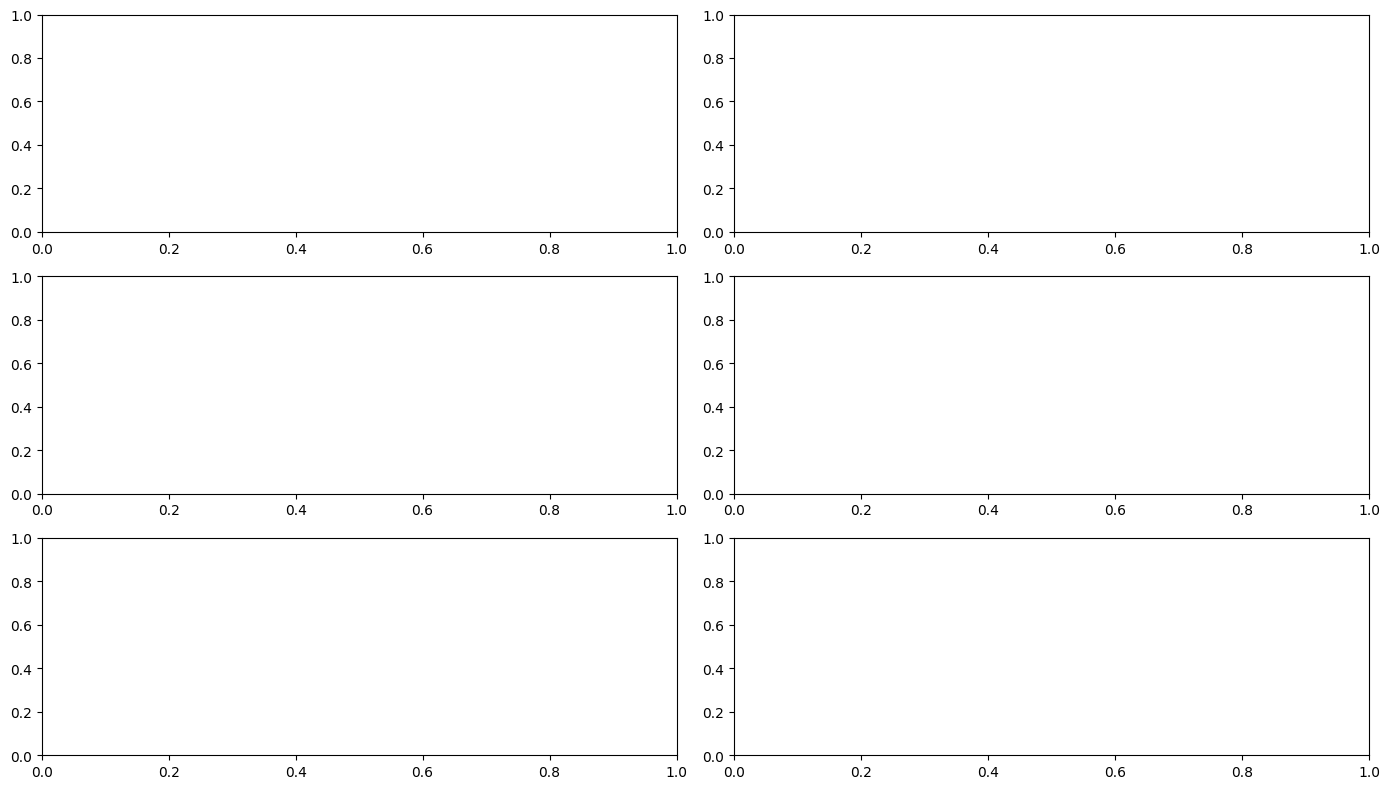

In [26]:
sano_wid = df_meta[df_meta[[f'label_F{i:02d}' for i in range(1, 14)]].sum(axis=1) == 0].iloc[0]
falla_mec = df_meta[df_meta['label_F01'] == 1].iloc[0] # Desbalance rotor
falla_elec = df_meta[df_meta['label_F08'] == 1].iloc[0] # Desequilibrio tensión
falla_hidr = df_meta[df_meta['label_F12'] == 1].iloc[0] # Cavitación

def plot_time_series(wid_row, channel, fs, ax, title):
    file_path = os.path.join(nnoutput_dir, 'datos', sample_row['file'])
    with np.load(file_path) as data:
        sig = data[f"{wid_row['window_id']}__{channel}"]
    t = np.arange(len(sig)) / fs
    ax.plot(t[:min(len(t), int(fs * 0.2))], lw=0.8) # Graficar primeros 200 ms
    ax.set_title(title)
    ax.set_xlabel('Tiempo [s]')
    ax.grid(True, alpha=0.3)

fig, axes = plt.subplots(3, 2, figsize=(14, 8), tight_layout=True)
plot_time_series(sano_wid, 'acc_radial_a', 20000, axes[0, 0], 'Acc - Sano')
plot_time_series(falla_mec, 'acc_radial_a', 20000, axes[0, 1], 'Acc - Falla Mecánica (F01)')
plot_time_series(sano_wid, 'current_a', 10000, axes[1, 0], 'Current - Sano')
plot_time_series(falla_elec, 'current_a', 10000, axes[1, 1], 'Current - Falla Eléctrica (F08)')
plot_time_series(sano_wid, 'pressure_in', 200, axes[2, 0], 'Pressure - Sano')
plot_time_series(falla_hidr, 'pressure_in', 200, axes[2, 1], 'Pressure - Falla Hidráulica (F12)')
plt.show()

# Etapa 5 — Señales crudas (NPZ)

Continuacion de `eda_y_benchmark__base4.5.ipynb`. Este bloque agrega la unica
informacion que las tablas no tienen y la somete a la misma prueba que todo lo
demas antes de aceptarla.

**Que se extrae, y por que solo eso.** La tabla ya trae por canal el valor
eficaz, la curtosis, el factor de cresta y las amplitudes a 1x y 2x.
Recalcularlos desde la senal da el mismo numero y no aporta nada. Lo que solo
vive en la senal es:

| Bloque | Que se calcula | Que falla ataca |
|---|---|---|
| Envolvente | banda resonante por curtosis, transformada de Hilbert, espectro de la envolvente | F03, F04, F05 — los tres tipos de dano de rodamiento, que hoy se confunden entre si |
| Perfil de ordenes | energia de la envolvente en 29 ordenes de la frecuencia de giro, de 1,00 a 8,00 | idem, **sin necesidad de conocer la geometria del rodamiento** |
| MCSA | bandas laterales de la corriente en (1 ± 2s)·f y armonicos impares | F10 barras rotoricas, F11 espiras, F08 desequilibrio |
| Presion | fraccion de energia en alta frecuencia, curtosis, entropia espectral | F12 cavitacion, F13 obstruccion |

Son **69 variables nuevas** por ventana, mas su version normalizada por maquina.

**La decision de geometria.** Las frecuencias de defecto de un rodamiento
dependen de su geometria (numero de elementos, diametros, angulo de contacto),
que la consigna no da. En vez de adivinarla, se calculan las dos cosas: los
ordenes tipicos como candidatos y **el perfil completo de ordenes**, para que
el modelo encuentre solo donde esta el pico.

**La compuerta.** Al final se mide, con el protocolo de cinco cortes de
regimen, si agregar estas variables mejora o no. **Si no mejora, el notebook
usa la configuracion tabular sola.** Por construccion la version 5 no puede
quedar por debajo de la 4.5.

## 5.1 Descarga de las señales

In [ ]:
import os, sys, zipfile, time
from pathlib import Path
import numpy as np
import pandas as pd

RAW_ZIP_ID = "1UdpBxRhFeHyZtEAORYDGwIPqYxAKD_mw"      # datos.zip con raw_signals/ (663 MB)
RAW_DIR    = Path("./data_from_raw")

def buscar_npz(raiz):
    """os.walk en vez de rglob: rglob no entra en directorios enlazados."""
    out = []
    for base, _, files in os.walk(raiz, followlinks=True):
        out += [Path(base) / f for f in files if f.endswith(".npz")]
    return sorted(out)

if not RAW_DIR.exists() or not buscar_npz(RAW_DIR):
    import gdown
    gdown.download(id=RAW_ZIP_ID, output="datos_raw.zip", quiet=False)
    RAW_DIR.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile("datos_raw.zip") as zf:
        zf.extractall(RAW_DIR)
    os.remove("datos_raw.zip")

NPZ = buscar_npz(RAW_DIR)
print("archivos NPZ encontrados:", len(NPZ))
assert NPZ, "no se encontraron NPZ: revisar la descarga"
CARPETA_NPZ = NPZ[0].parent
print("carpeta:", CARPETA_NPZ)

# Indice que mapea cada ventana a su archivo y canales
raw_index = pd.read_parquet(DATA / "raw_signal_index.parquet")
print("ventanas indexadas:", len(raw_index),
      "| cubren train:", raw_index.window_id.isin(train.window_id).sum(),
      "| cubren test:", raw_index.window_id.isin(test.window_id).sum())

In [ ]:
# Verificacion de formato antes de procesar 4032 ventanas
with np.load(CARPETA_NPZ / Path(raw_index.file.iloc[0]).name) as z:
    claves = list(z.keys())
    print("claves por archivo:", len(claves), "(7 ventanas x 3 canales)")
    print("ejemplo:", claves[:3])
    for ch, fs in [("acc_radial_a", 20000), ("current_a", 10000), ("pressure_in", 200)]:
        k = [c for c in claves if c.endswith(ch)][0]
        n = len(z[k])
        print("  %-14s %6d muestras = %.2f s a %d Hz" % (ch, n, n / fs, fs))

## 5.2 Extracción de variables

In [ ]:
from scipy.signal import hilbert, welch, butter, sosfiltfilt, decimate

FS = {"acc_radial_a": 20000, "current_a": 10000, "pressure_in": 200}
ORDENES = {"BPFO": 3.585, "BPFI": 5.415, "BSF": 2.357, "FTF": 0.398}
PERFIL  = np.round(np.arange(1.0, 8.01, 0.25), 2)     # 29 ordenes de fr

def _psd(x, fs, nper):
    f, p = welch(x, fs=fs, nperseg=int(min(nper, len(x))), detrend="constant")
    return f, p

def _pico(f, p, obj, tol=0.04):
    """Altura del pico cerca de `obj`, relativa a la mediana del espectro."""
    if obj <= 0 or obj >= f[-1]:
        return 0.0
    m = (f > obj * (1 - tol)) & (f < obj * (1 + tol))
    return float(p[m].max() / (np.median(p) + 1e-20)) if m.any() else 0.0

def _entropia(p):
    q = p / (p.sum() + 1e-20)
    return float(-(q * np.log(q + 1e-20)).sum())

def banda_resonante(x, fs, n_bandas=6):
    """Kurtograma simplificado: la banda de mayor curtosis es donde el defecto
    de rodamiento modula la resonancia estructural. Ahi hay que demodular."""
    nyq = fs / 2.0
    mejor, k_mejor = (0.25 * nyq, 0.5 * nyq), -np.inf
    for i in range(n_bandas):
        lo, hi = max(i * nyq / n_bandas, 20.0), min((i + 1) * nyq / n_bandas, nyq * 0.995)
        if hi - lo < 100:
            continue
        y = sosfiltfilt(butter(4, [lo / nyq, hi / nyq], btype="band", output="sos"), x)
        v = y.var()
        if v <= 0:
            continue
        k = float(((y - y.mean()) ** 4).mean() / (v ** 2))
        if k > k_mejor:
            k_mejor, mejor = k, (lo, hi)
    return mejor, k_mejor

def feats_acc(x, fs, rpm):
    fr = max(rpm, 1.0) / 60.0
    (lo, hi), kres = banda_resonante(x, fs)
    d = {"env_band_lo": lo, "env_band_hi": hi, "env_kurt_res": kres}

    sos = butter(4, [lo / (fs / 2), min(hi, fs / 2 * 0.995) / (fs / 2)],
                 btype="band", output="sos")
    env = np.abs(hilbert(sosfiltfilt(sos, x)))
    env = decimate(env - env.mean(), 10, ftype="fir", zero_phase=True)
    f, p = _psd(env, fs / 10.0, 4096)

    for nom, r in ORDENES.items():                    # candidatos por geometria tipica
        d["env_" + nom] = _pico(f, p, fr * r)
        d["env_" + nom + "_2"] = _pico(f, p, 2 * fr * r)
    for o in PERFIL:                                  # perfil, sin suponer geometria
        d["env_ord_%.2f" % o] = _pico(f, p, fr * o)

    tot = p.sum() + 1e-20
    d["env_frac_1_5fr"] = float(p[f < 5 * fr].sum() / tot)
    d["env_entropia"]   = _entropia(p)
    d["env_pico_max"]   = float(p.max() / (np.median(p) + 1e-20))
    d["env_ord_pico"]   = float(f[int(np.argmax(p))] / (fr + 1e-9))

    f2, p2 = _psd(x, fs, 4096)
    t2 = p2.sum() + 1e-20
    for a, b, nom in [(0, 500, "b0"), (500, 2000, "b1"), (2000, 5000, "b2"), (5000, 10000, "b3")]:
        d["acc_frac_" + nom] = float(p2[(f2 >= a) & (f2 < b)].sum() / t2)
    d["acc_entropia"] = _entropia(p2)
    return d

def feats_cur(x, fs, rpm, f_red=50.0):
    f, p = _psd(x, fs, 8192)
    d = {}
    p0 = p[int(np.argmin(np.abs(f - f_red)))] + 1e-20
    for s in (0.01, 0.02, 0.03, 0.05):                # deslizamientos candidatos
        izq, der = _pico(f, p, f_red * (1 - 2 * s)), _pico(f, p, f_red * (1 + 2 * s))
        d["mcsa_sb%d" % int(s * 100)]   = float((izq + der) / 2)
        d["mcsa_asim%d" % int(s * 100)] = float(abs(izq - der) / (izq + der + 1e-9))
    for h in (3, 5, 7):
        d["mcsa_h%d" % h] = float(p[int(np.argmin(np.abs(f - f_red * h)))] / p0)
    fr = max(rpm, 1.0) / 60.0
    d["mcsa_fr"]  = _pico(f, p, fr)
    d["mcsa_2fr"] = _pico(f, p, 2 * fr)
    d["cur_frac_alta"] = float(p[f > 1000].sum() / (p.sum() + 1e-20))
    d["cur_entropia"]  = _entropia(p)
    return d

def feats_pre(x, fs):
    f, p = _psd(x, fs, 256)
    tot, v = p.sum() + 1e-20, x.var()
    return {"pre_frac_alta":  float(p[f > f[-1] * 0.5].sum() / tot),
            "pre_frac_media": float(p[(f > f[-1] * 0.2) & (f <= f[-1] * 0.5)].sum() / tot),
            "pre_entropia":   _entropia(p),
            "pre_kurt":       float(((x - x.mean()) ** 4).mean() / (v ** 2 + 1e-12)) if v > 0 else 0.0,
            "pre_cv":         float(np.sqrt(v) / (abs(x.mean()) + 1e-9))}

def feats_ventana(sig, rpm):
    d = {}
    if "acc_radial_a" in sig: d.update(feats_acc(np.asarray(sig["acc_radial_a"], float), FS["acc_radial_a"], rpm))
    if "current_a"    in sig: d.update(feats_cur(np.asarray(sig["current_a"], float), FS["current_a"], rpm))
    if "pressure_in"  in sig: d.update(feats_pre(np.asarray(sig["pressure_in"], float), FS["pressure_in"]))
    return d

print("variables por ventana:", len(feats_ventana(
    {"acc_radial_a": np.random.default_rng(0).normal(size=40000),
     "current_a":    np.random.default_rng(1).normal(size=20000),
     "pressure_in":  np.random.default_rng(2).normal(size=400)}, 1800.0)))

In [ ]:
CACHE = Path("raw_features.parquet")

def extraer_todo(index_df, rpm_map):
    filas, faltan, t0 = [], 0, time.time()
    for archivo, g in index_df.groupby("file"):
        ruta = CARPETA_NPZ / Path(archivo).name
        if not ruta.exists():
            faltan += len(g); continue
        with np.load(ruta) as z:
            for wid in g.window_id:
                sig = {ch: z[f"{wid}__{ch}"] for ch in FS if f"{wid}__{ch}" in z}
                if not sig:
                    faltan += 1; continue
                d = feats_ventana(sig, float(rpm_map.get(wid, 1800.0)))
                d["window_id"] = wid
                filas.append(d)
        if len(filas) and len(filas) % 700 == 0:
            print("  %4d ventanas  (%.1f min)" % (len(filas), (time.time() - t0) / 60), flush=True)
    print("extraidas %d ventanas, %d sin senal, %.1f min"
          % (len(filas), faltan, (time.time() - t0) / 60))
    return pd.DataFrame(filas)

if CACHE.exists():
    RAW = pd.read_parquet(CACHE)
    print("cache leida:", RAW.shape)
else:
    rpm_map = dict(zip(pd.concat([train[["window_id", "rpm_mean"]],
                                  test[["window_id", "rpm_mean"]]]).window_id,
                       pd.concat([train[["window_id", "rpm_mean"]],
                                  test[["window_id", "rpm_mean"]]]).rpm_mean))
    RAW = extraer_todo(raw_index[raw_index.window_id.isin(rpm_map)], rpm_map)
    RAW.to_parquet(CACHE, index=False)
    print("guardado en", CACHE)

RAW_COLS = [c for c in RAW.columns if c != "window_id"]
print("variables crudas:", len(RAW_COLS))

## 5.3 Construcción de la matriz combinada

In [ ]:
def con_crudas(df_base, X_tab):
    """Pega las variables crudas y su z-score por maquina a la matriz tabular."""
    m = df_base[["window_id", "machine_id"]].merge(RAW, on="window_id", how="left")
    g = m.groupby("machine_id")[RAW_COLS]
    z = (m[RAW_COLS] - g.transform("median")) / (g.transform("std") + 1e-9)
    z.columns = [c + "__z" for c in RAW_COLS]
    bloque = pd.concat([m[RAW_COLS].reset_index(drop=True), z.reset_index(drop=True)], axis=1)
    out = pd.concat([X_tab.reset_index(drop=True), bloque], axis=1)
    return out.replace([np.inf, -np.inf], np.nan).fillna(0.0)

X_tab_train = construir(train, "fis_z")
X_tab_test  = construir(test,  "fis_z").reindex(columns=X_tab_train.columns)

X_mix_train = con_crudas(train, X_tab_train)
X_mix_test  = con_crudas(test,  X_tab_test).reindex(columns=X_mix_train.columns).fillna(0.0)

# GUARDA DE COBERTURA. Si a alguna ventana le falta senal, el merge deja NaN,
# el fillna(0) los tapa y el submit sale mal SIN AVISAR. Hay que detectarlo aca.
cob_tr = train.window_id.isin(RAW.window_id).mean()
cob_te = test.window_id.isin(RAW.window_id).mean()
print("cobertura de senal cruda -> train: %.1f %%   test: %.1f %%" % (100 * cob_tr, 100 * cob_te))

COBERTURA_OK = (cob_tr > 0.99) and (cob_te > 0.99)
if not COBERTURA_OK:
    print("\n*** ATENCION: faltan senales para %d ventanas de train y %d de test."
          % ((~train.window_id.isin(RAW.window_id)).sum(),
             (~test.window_id.isin(RAW.window_id)).sum()))
    print("    Las variables crudas NO se van a usar: con cobertura parcial el")
    print("    modelo aprende a distinguir 'tiene senal' en vez de la falla.")

print("\nA) solo tabular      :", X_tab_train.shape)
print("B) tabular + crudas  :", X_mix_train.shape)

## 5.4 La compuerta: ¿las variables crudas mejoran o no?

Se mide con el protocolo que ya veniamos usando: **cinco cortes por regimen**.
Se ordenan las 26 maquinas por rpm, se entrena con las k mas lentas y se valida
con el resto, para k entre 11 y 15. Un solo corte es demasiado ruidoso —su
desvio es de aproximadamente 1 punto— asi que se promedian los cinco.

Se compara la configuracion tabular contra la tabular mas crudas, **con el
mismo ensamble que produjo los 48,1150**: LightGBM + RandomForest + regresion
logistica, promedio simple de probabilidades y media geometrica por sesion.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import lightgbm as lgb

RS = 42

def mk_lgb(s=RS):
    return lgb.LGBMClassifier(objective="multiclass", num_class=14, n_estimators=500,
        learning_rate=0.05, num_leaves=15, min_child_samples=25, subsample=0.9,
        subsample_freq=1, colsample_bytree=0.7, reg_lambda=5.0, verbose=-1,
        random_state=s, deterministic=True, force_col_wise=True, n_jobs=1)

def mk_rf(s=RS):
    return make_pipeline(SimpleImputer(strategy="median"),
        RandomForestClassifier(n_estimators=600, min_samples_leaf=2,
                               max_features="sqrt", n_jobs=1, random_state=s))

def mk_lr(s=RS):
    return make_pipeline(SimpleImputer(strategy="median"), StandardScaler(),
        LogisticRegression(max_iter=2000, C=0.5, random_state=s))

ENSAMBLE = (mk_lgb, mk_rf, mk_lr)      # el de base4.5

SES_TR  = train.session_id.to_numpy()
RPM_MAQ = train.groupby("machine_id").rpm_mean.mean().sort_values()
CORTES  = [11, 12, 13, 14, 15]

def evaluar_idx(P13, idx):
    e = pd.DataFrame({"window_id": train.window_id.iloc[idx].to_numpy()})
    for j, f in enumerate(FAULT_IDS):
        e[f] = np.clip(P13[:, j], 0, 1)
    return compute_score(train.iloc[idx], e)["overall"]

def promedio_sesion(P, ses):
    d = pd.DataFrame(P); d["s"] = ses
    g = np.exp(d.groupby("s").transform(lambda v: np.log(np.clip(v, 1e-9, 1)).mean())).to_numpy()
    return g / g.sum(axis=1, keepdims=True)

def score_regimen(X, detalle=False):
    vals = []
    for k in CORTES:
        rapidas = set(RPM_MAQ.index[k:])
        es_rap = train.machine_id.isin(rapidas).to_numpy()
        a, b = np.where(~es_rap)[0], np.where(es_rap)[0]
        P = np.mean([m(RS).fit(X.iloc[a], estado[a]).predict_proba(X.iloc[b])
                     for m in ENSAMBLE], axis=0)
        P = P / P.sum(axis=1, keepdims=True)
        P = promedio_sesion(P, SES_TR[b])
        vals.append(evaluar_idx(P[:, 1:], b)["final_score"])
    return (float(np.mean(vals)), float(np.std(vals)), vals) if detalle else \
           (float(np.mean(vals)), float(np.std(vals)))

mA, sA, vA = score_regimen(X_tab_train, detalle=True)
print("A) solo tabular       %6.2f +- %.2f   %s" % (mA, sA, " ".join("%.1f" % v for v in vA)))
if COBERTURA_OK:
    mB, sB, vB = score_regimen(X_mix_train, detalle=True)
    print("B) tabular + crudas   %6.2f +- %.2f   %s" % (mB, sB, " ".join("%.1f" % v for v in vB)))
else:
    mB, sB, vB = float("-inf"), 0.0, [float("-inf")] * len(CORTES)
    print("B) tabular + crudas   no se evalua: cobertura incompleta")

In [ ]:
# La regla: las crudas entran solo si mejoran de forma consistente.
# Se exige superar a la tabular en la media Y en al menos 4 de los 5 cortes.
gana_cortes = sum(b > a for a, b in zip(vA, vB))
USAR_CRUDAS = COBERTURA_OK and (mB > mA) and (gana_cortes >= 4)

print("mejora media        : %+.2f" % (mB - mA))
print("cortes en que gana  : %d de 5" % gana_cortes)
print()
if not COBERTURA_OK:
    print(">>> COBERTURA INSUFICIENTE: no se usan las crudas por seguridad.")
if USAR_CRUDAS:
    print(">>> SE ADOPTAN las variables crudas. Configuracion final: tabular + crudas.")
    X_FINAL_TRAIN, X_FINAL_TEST, ETIQUETA = X_mix_train, X_mix_test, "tabular+crudas"
else:
    print(">>> NO se adoptan: la mejora no es consistente.")
    print("    Configuracion final: solo tabular, identica a la version 4.5.")
    X_FINAL_TRAIN, X_FINAL_TEST, ETIQUETA = X_tab_train, X_tab_test, "solo tabular"
print("matriz elegida:", X_FINAL_TRAIN.shape)

Esa condicion —ganar en la media **y** en cuatro de los cinco cortes— es lo que
impide repetir el error de las etapas anteriores, donde se acepto una mejora
que resulto ser ruido de particion y termino bajando el puntaje del servidor.
Si las variables crudas no pasan, la version 5 entrega exactamente lo mismo que
la 4.5 y no se pierde nada.

## 5.5 ¿Qué aportan las variables crudas? (solo si entraron)

In [ ]:
if USAR_CRUDAS:
    from sklearn.metrics import roc_auc_score
    print("AUC de la mejor variable cruda para cada falla:\n")
    base = train[["window_id"]].assign(e=estado).merge(RAW, on="window_id", how="left")
    for k in range(1, 14):
        y = (base.e == k).astype(int)
        if y.sum() < 10:
            continue
        mejor = max((roc_auc_score(y, base[c].fillna(0)), c) for c in RAW_COLS)
        marca = "  <-- rodamiento" if k in (3, 4, 5) else ""
        print("  F%02d  AUC = %.3f   %s%s" % (k, mejor[0], mejor[1], marca))
else:
    print("Las crudas no entraron: no corresponde analizarlas como aporte.")

## 5.6 Modelo final y entrega

In [ ]:
print("entrenando el ensamble final sobre:", ETIQUETA)
preds = []
for m in ENSAMBLE:
    mod = m(RS)
    mod.fit(X_FINAL_TRAIN, estado)
    preds.append(mod.predict_proba(X_FINAL_TEST))
    print("  modelo listo")

P_test = np.mean(preds, axis=0)
P_test = P_test / P_test.sum(axis=1, keepdims=True)

d = pd.DataFrame(P_test); d["s"] = test.session_id.to_numpy()
P_test = np.exp(d.groupby("s").transform(lambda v: np.log(np.clip(v, 1e-9, 1)).mean())).to_numpy()
# to_numpy() sobre un groupby devuelve un array de solo lectura: no dividir en sitio
P_test = P_test / P_test.sum(axis=1, keepdims=True)

submission = pd.DataFrame({"window_id": test.window_id.to_numpy()})
for j, f in enumerate(FAULT_IDS):
    submission[f] = np.clip(P_test[:, j + 1], 0, 1)
submission = validate_prediction_package(test, submission)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
ruta = OUTPUT_DIR / "submit_v5.csv"
submission.to_csv(ruta, index=False)

import hashlib
print("\narchivo:", ruta)
print("md5    :", hashlib.md5(ruta.read_bytes()).hexdigest())
print("filas  :", len(submission), "de", len(test))
display(submission.head())

In [ ]:
P = submission[FAULT_IDS].to_numpy()
assert submission.shape == (len(test), 14)
assert list(submission.columns) == ["window_id"] + FAULT_IDS
assert submission.window_id.is_unique and set(submission.window_id) == set(test.window_id)
assert np.isfinite(P).all() and (P >= 0).all() and (P <= 1).all()
print("formato validado")
print("configuracion enviada:", ETIQUETA)
print("estimacion por regimen: %.2f" % (mB if USAR_CRUDAS else mA))
print("Sp media: %.3f  (prevalencia del train: %.3f)" % (P.sum(1).mean(), (estado > 0).mean()))

import scoring
acc = [scoring.choose_action({f: float(P[i, j]) for j, f in enumerate(FAULT_IDS)})
       for i in range(len(P))]
print("\nacciones que induce la entrega:")
print(pd.Series([a + "/" + (b or "") for a, b in acc]).value_counts().to_string())

## 5.7 Cómo leer el resultado

El estimador por cambio de regimen **subestima** de manera sistematica: la
configuracion tabular da alrededor de 43 en este esquema y saco 48,1150 en el
servidor. La diferencia son unos cuatro puntos y va a favor.

Con eso, la lectura de la salida de la compuerta es:

- Si las crudas entraron y la mejora es de **+2 o mas**, es razonable esperar
  superar los 48,1150.
- Si entraron con **menos de +2**, la mejora es real pero chica: conviene
  mirarla junto al desvio antes de gastar un envio.
- Si **no entraron**, la entrega es identica a la de la version 4.5. No se
  pierde nada, y el resultado negativo igual vale: queda documentado que las
  variables de envolvente y MCSA no aportan sobre estos datos, que es
  informacion util para el probatorio.

Lo que **no** se puede afirmar de antemano es cual de los tres casos va a
ocurrir. El notebook lo mide y decide solo.